- This notebook explores typical Machine Learning models from a high perspective, where deep dives will be on different notebooks if necessary.
- The detail inner working of the models are in another notebook, and this notebook is meant to show a summary knowledge of common machine learning model.

# Supervised Learning Models

## 1. Linear Regression (Regression)
- Linear regression is a statistical model that predicts a dependent variable by fitting a linear relationship to one or more independent variables. 
- The goal is to find the best-fit line (or hyperplane in higher dimensions) that minimizes the sum of squared errors between the predicted values and the actual values.
- **Numerical Equation:**
    - For multiple linear regression with $p$ independent variables, 
    - $y = \beta\_0 + \beta\_1x\_1 + \beta\_2x\_2 + ... + \beta\_px\_p + \epsilon$
        - $y$ is the **dependent variable**.
        - $x\_i$ represents the **independent variables**.
        - $\\beta\_0$ is the **y-intercept**.
        - $\\beta\_i$ are the **coefficients** or **weights**.
        - $\\epsilon$ is the **error term**.
- The coefficients are estimated using the **Ordinary Least Squares (OLS)** method, which minimizes the
 **Residual Sum of Squares (RSS)**:

    $RSS = \sum_{i=1}^{n} (y_i - \hat{y}*i)^2 = \sum_{i=1}^{n} (y_i - (\beta_0 + \sum_{j=1}^{p} \beta_j x_{ij}))^2$
- **Pseudocode**
    ~~~
    Function LinearRegression_Train(X_train, y_train):
        // Solve for coefficients using OLS
        // Using matrix notation, beta_hat = (X^T * X)^-1 * X^T * y
        // where X is the design matrix and y is the target vector
        beta = (X_train.T * X_train)^-1 * X_train.T * y_train
        Return beta

    Function LinearRegression_Predict(X_test, beta):
        y_predict = X_test * beta
        Return y_predict
    ~~~


Mean Squared Error: 0.55
Intercept (beta_0): 0.44
Coefficient (beta_1): 0.40


/home/troll/miniconda3/envs/random/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


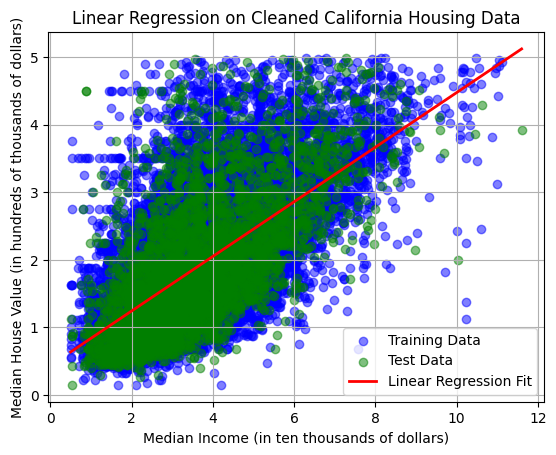

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.datasets import fetch_california_housing

# --- Dataset Setup ---
# Load the California Housing dataset
california_housing = fetch_california_housing(as_frame=True)

# Select 'MedInc' as the feature and 'MedHouseVal' as the target
X = california_housing.frame[['MedInc']]
y = california_housing.target

# --- Data Cleaning ---
# 1. Remove rows where the target variable is truncated (equal to 5.0). 
mask = y < 5.0
X_cleaned = X[mask]
y_cleaned = y[mask]

# 2. Remove extreme outliers based on median income.
# This helps the model focus on the main distribution.
# For example, filter out any income > 12.0
outlier_mask = X_cleaned['MedInc'] < 12.0
X_cleaned = X_cleaned[outlier_mask]
y_cleaned = y_cleaned[outlier_mask]

# --- Model Building ---
# Split the cleaned data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_cleaned, y_cleaned, test_size=0.2, random_state=42)

# Create and train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")

# Display the learned coefficients
print(f"Intercept (beta_0): {model.intercept_:.2f}")
print(f"Coefficient (beta_1): {model.coef_[0]:.2f}")


# --- Plotting ---
# Create a scatter plot of the training data
plt.scatter(X_train, y_train, color='blue', label='Training Data', alpha=0.5)

# Create a scatter plot of the test data
plt.scatter(X_test, y_test, color='green', label='Test Data', alpha=0.5)

# Plot the regression line
X_range = np.linspace(X_cleaned.min(), X_cleaned.max(), 100).reshape(-1, 1)
y_line = model.predict(X_range)
plt.plot(X_range, y_line, color='red', linewidth=2, label='Linear Regression Fit')

# Add labels and a title
plt.title('Linear Regression on Cleaned California Housing Data')
plt.xlabel('Median Income (in ten thousands of dollars)')
plt.ylabel('Median House Value (in hundreds of thousands of dollars)')
plt.legend()
plt.grid(True)
plt.show()

Note:
- The code cleans the dataset as the dataset comes truncated at median house value of 5. 
- A linear best fit line can be seen in the graph.

---
## 2. Perceptron (Binary Classification)
- The Perceptron is a single-layer neural network and a foundational binary classification algorithm.
- It learns a linear decision boundary (a hyperplane) to separate two classes of data. The model makes a prediction by taking a weighted sum of the inputs and passing it through a step function.
- _Basically a single neuron of a neural network. It can only draw a straight line._ 
- **Numerical Equation:**
    - The output $\hat{y}$ is:
    - $\hat{y} = \text{sign}(\sum_{i=1}^n w_i x_i + b)$
        - $w\_i$ are the **weights**.
        - $x\_i$ are the input features.
        - $b$ is the **bias**.
        - $\text{sign}$ is a step function that outputs +1 if the sum is positive and -1 otherwise.
    - The weights are updated on a misclassified example $(x\_j, y\_j)$ with a learning rate $\alpha$:
    - $w\_i^{new} = w\_i^{old} + \alpha \cdot (y\_j - \hat{y}*j) \cdot x*{ji}$
    - $b^{new} = b^{old} + \alpha \cdot (y\_j - \hat{y}\_j)$
- **Pseudocode:**
    ```
    Function Perceptron_Train(X_train, y_train, learning_rate, epochs):
        Initialize weights w and bias b to small random values or zero
        For each epoch from 1 to epochs:
            For each training example (x, y) in X_train, y_train:
                // Calculate predicted output
                y_pred = sign(dot_product(w, x) + b)

                // Update weights if misclassified
                error = y - y_pred
                If error != 0:
                    w = w + learning_rate * error * x
                    b = b + learning_rate * error
        Return w, b
    ```



Accuracy: 1.00
Weights (w): [[10.63414049 -3.61008048]]
Bias (b): 1.0


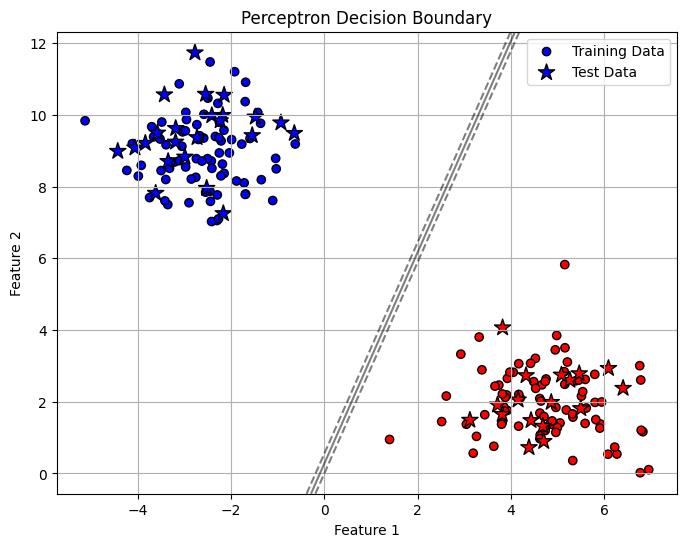

In [2]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

# --- Dataset Setup ---
# Generate a linearly separable dataset with 2 classes
# We use make_blobs to create two distinct clusters
X, y = make_blobs(n_samples=200, centers=2, n_features=2, random_state=42)

# Perceptron works with binary classes, often represented as -1 and 1.
# We'll convert our 0s and 1s to -1s and 1s for best practice.
y[y == 0] = -1

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- Model Building ---
# Create and train the Perceptron model
# The `fit` method iteratively adjusts the weights to minimize misclassifications
model = Perceptron(max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

# Display the learned parameters
print(f"Weights (w): {model.coef_}")
print(f"Bias (b): {model.intercept_[0]}")

# --- Plotting ---
plt.figure(figsize=(8, 6))

# Plot the training data points
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap='bwr', edgecolor='k', label='Training Data')

# Plot the testing data points
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='bwr', edgecolor='k', marker='*', s=150, label='Test Data')

# Create a mesh grid to plot the decision boundary
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()

# Create a grid to evaluate the model on
xx = np.linspace(xlim[0], xlim[1], 30)
yy = np.linspace(ylim[0], ylim[1], 30)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T

# Use the model to predict the class for each point in the grid
Z = model.decision_function(xy).reshape(XX.shape)

# Plot the decision boundary and the margin
ax.contour(XX, YY, Z, colors='k', levels=[-1, 0, 1], alpha=0.5, linestyles=['--', '-', '--'])

# Add labels and a title
plt.title('Perceptron Decision Boundary')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.grid(True)
plt.show()

---
## 3. K-Nearest Neighbors (KNN)
- KNN is a simple, **non-parametric**, and **lazy learning** algorithm. 
- For classification, a new data point is assigned the class of the majority of its **k** nearest neighbors. 
- For regression, it's assigned the average of the neighbors' values. The "distance" is typically measured using the Euclidean distance.
- **Numerical Equation:**
    - The Euclidean distance between two points $p$ and $q$ in $n$-dimensional space is:
    - $d(p, q) = \sqrt{\sum\_{i=1}^{n} (p\_i - q\_i)^2}$
- **Pseudocode:**
    ```
    Function KNN_Predict(X_train, y_train, X_test, k):
        predictions = []
        For each test_point in X_test:
            distances = []
            For each train_point in X_train:
                distance = calculate_euclidean_distance(test_point, train_point)
                distances.append(distance)
            
            // Find indices of k smallest distances
            k_nearest_indices = indices_of_k_smallest(distances)
            
            // Get labels of k nearest neighbors
            k_nearest_labels = [y_train[i] for i in k_nearest_indices]

            // For classification, get majority class
            predicted_label = most_frequent(k_nearest_labels)
            predictions.append(predicted_label)

        Return predictions
    ```



### KNN for Classification

- The code will have the model trained on all 4 features (petal length, petal width, sepal length, sepal width).
- The plot to show decision boundary and predicted vs actual will only use petal length and petal width.

Training the K-Nearest Neighbors model on Petal features...
Training complete.



/tmp/ipykernel_72948/3336237567.py:78: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax2.scatter(results_df.loc[predicted_indices, 'petal length (cm)'],


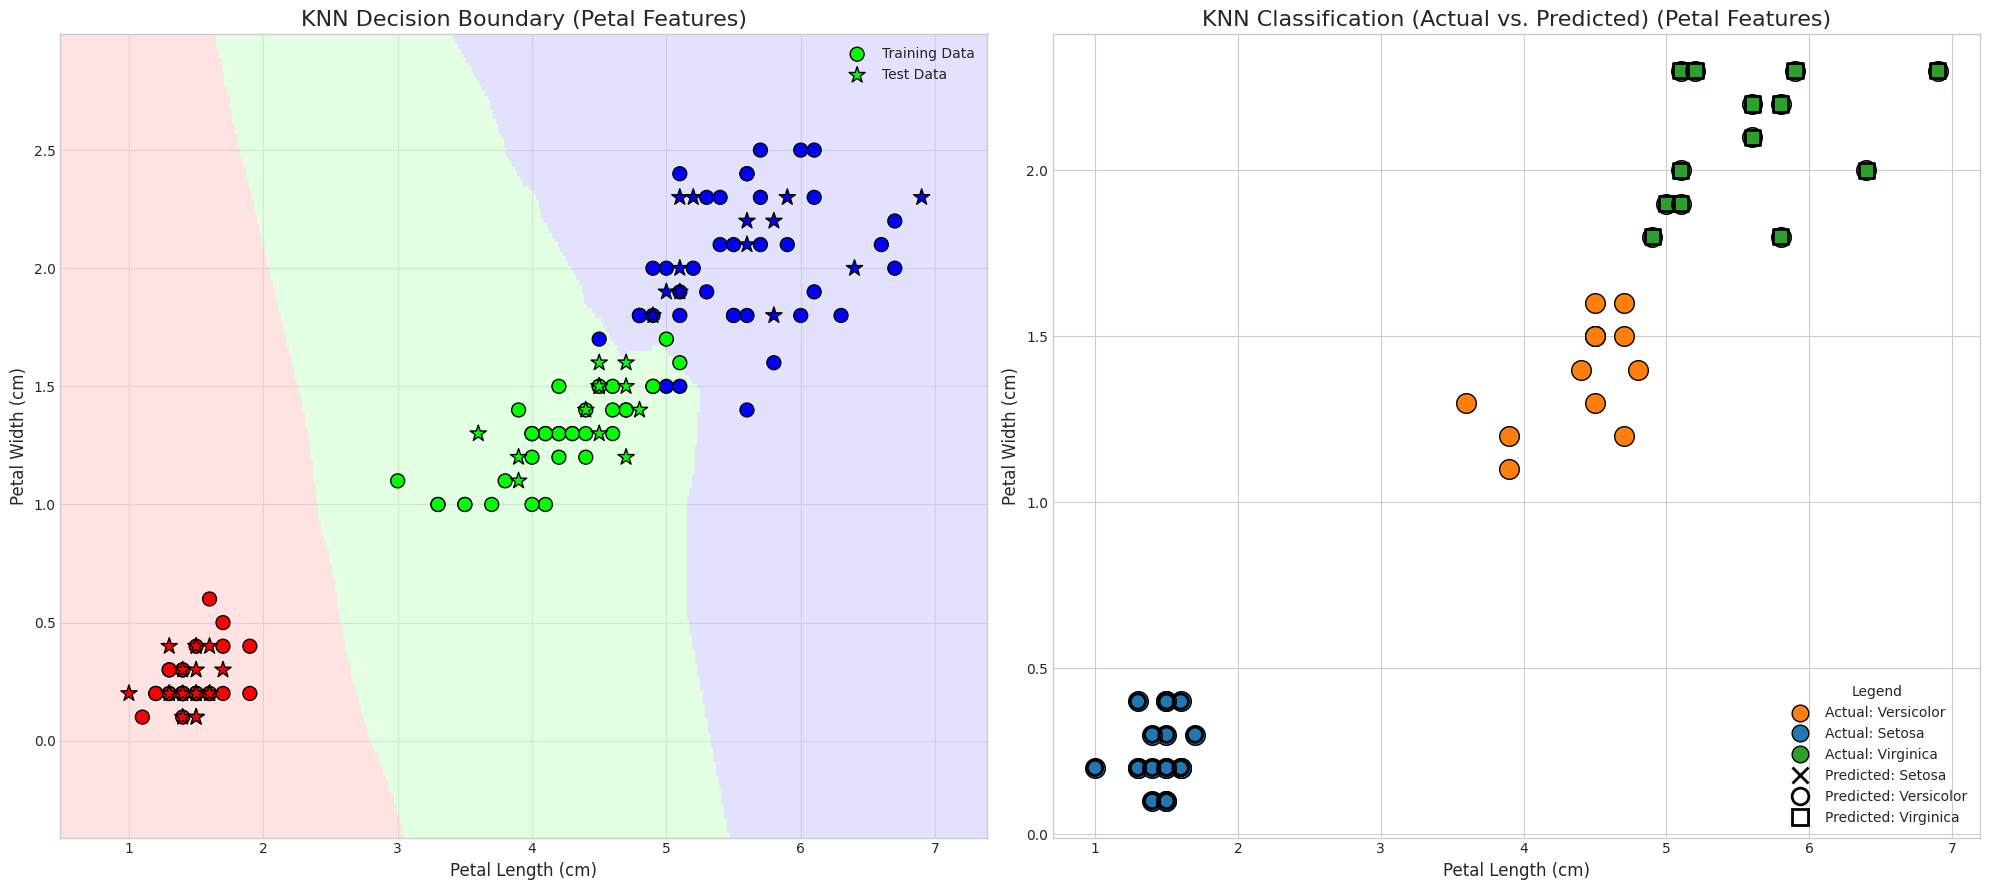


--- Classification Report (Petal Features) ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.datasets import load_iris

# --- Dataset setup ---
# We load the Iris dataset and focus on the petal features for both visualizations.
iris = load_iris()
X = iris.data[:, 2:]   # Petal Length and Petal Width
y = iris.target

# Split the data into training and testing sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# --- Model Building ---
# Initialize and train a single KNN model on the petal features.
knn = KNeighborsClassifier(n_neighbors=5)

print("Training the K-Nearest Neighbors model on Petal features...")
knn.fit(X_train, y_train)
print("Training complete.\n")

# Make predictions on the test set
y_pred = knn.predict(X_test)

# --- Plotting Both Graphs ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9))

# --- Graph 1: Decision Boundary Plot ---
cmap_light = ListedColormap(['#FFCFCF', '#CFFFCF', '#CFCFFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

Z = knn.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

ax1.pcolormesh(xx, yy, Z, cmap=cmap_light, shading='auto', alpha=0.6)
ax1.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap=cmap_bold,
            edgecolor='k', s=100, label='Training Data')
ax1.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap=cmap_bold,
            marker='*', edgecolor='k', s=150, label='Test Data')

ax1.set_title("KNN Decision Boundary (Petal Features)", fontsize=16)
ax1.set_xlabel("Petal Length (cm)", fontsize=12)
ax1.set_ylabel("Petal Width (cm)", fontsize=12)
ax1.legend(loc='upper right')
ax1.grid(True)

# --- Graph 2: Actual vs. Predicted Plot ---
results_df = pd.DataFrame(X_test, columns=['petal length (cm)', 'petal width (cm)'])
results_df['Actual Species'] = y_test
results_df['Predicted Species'] = y_pred

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
markers = ['o', 'x', 's']

for i, species_name in enumerate(iris.target_names):
    actual_indices = np.where(results_df['Actual Species'] == i)
    predicted_indices = np.where(results_df['Predicted Species'] == i)

    ax2.scatter(results_df.loc[actual_indices, 'petal length (cm)'],
                results_df.loc[actual_indices, 'petal width (cm)'],
                color=colors[i],
                marker='o',
                s=200,
                edgecolor='k',
                label=f'Actual: {species_name}')

    ax2.scatter(results_df.loc[predicted_indices, 'petal length (cm)'],
                results_df.loc[predicted_indices, 'petal width (cm)'],
                facecolors='none',
                edgecolor='k',
                marker=markers[i],
                s=120,
                linewidth=2,
                label=f'Predicted: {species_name}')

ax2.set_title('KNN Classification (Actual vs. Predicted) (Petal Features)', fontsize=16)
ax2.set_xlabel('Petal Length (cm)', fontsize=12)
ax2.set_ylabel('Petal Width (cm)', fontsize=12)

legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label='Actual: Versicolor',
               markerfacecolor=colors[1], markersize=12, markeredgecolor='k'),
    plt.Line2D([0], [0], marker='o', color='w', label='Actual: Setosa',
               markerfacecolor=colors[0], markersize=12, markeredgecolor='k'),
    plt.Line2D([0], [0], marker='o', color='w', label='Actual: Virginica',
               markerfacecolor=colors[2], markersize=12, markeredgecolor='k'),
    plt.Line2D([0], [0], marker='x', color='k', linestyle='None',
               label='Predicted: Setosa', markersize=12, markeredgewidth=2),
    plt.Line2D([0], [0], marker='o', color='k', linestyle='None',
               label='Predicted: Versicolor', markersize=12, markeredgewidth=2, fillstyle='none'),
    plt.Line2D([0], [0], marker='s', color='k', linestyle='None',
               label='Predicted: Virginica', markersize=12, markeredgewidth=2, fillstyle='none')
]

ax2.legend(handles=legend_elements, title='Legend', loc='lower right', fontsize=10)
ax2.grid(True)

plt.tight_layout()
plt.show()

# --- Print Classification Report ---
print("\n--- Classification Report (Petal Features) ---")
print(classification_report(y_test, y_pred, target_names=iris.target_names))


- **Decision Boundaries**: The colored regions (light red, light green, and light blue) represent the decision boundaries learned by the K-Nearest Neighbors (KNN) model. Any new data point falling into a specific color zone would be classified as that color's corresponding class.
- **Features**: The two features used for classification are sepal length on the x-axis and sepal width on the y-axis. The graph shows that these two features are sufficient to largely separate the three classes of Iris flowers.

### KNN for Regression

Mean Squared Error: 0.64


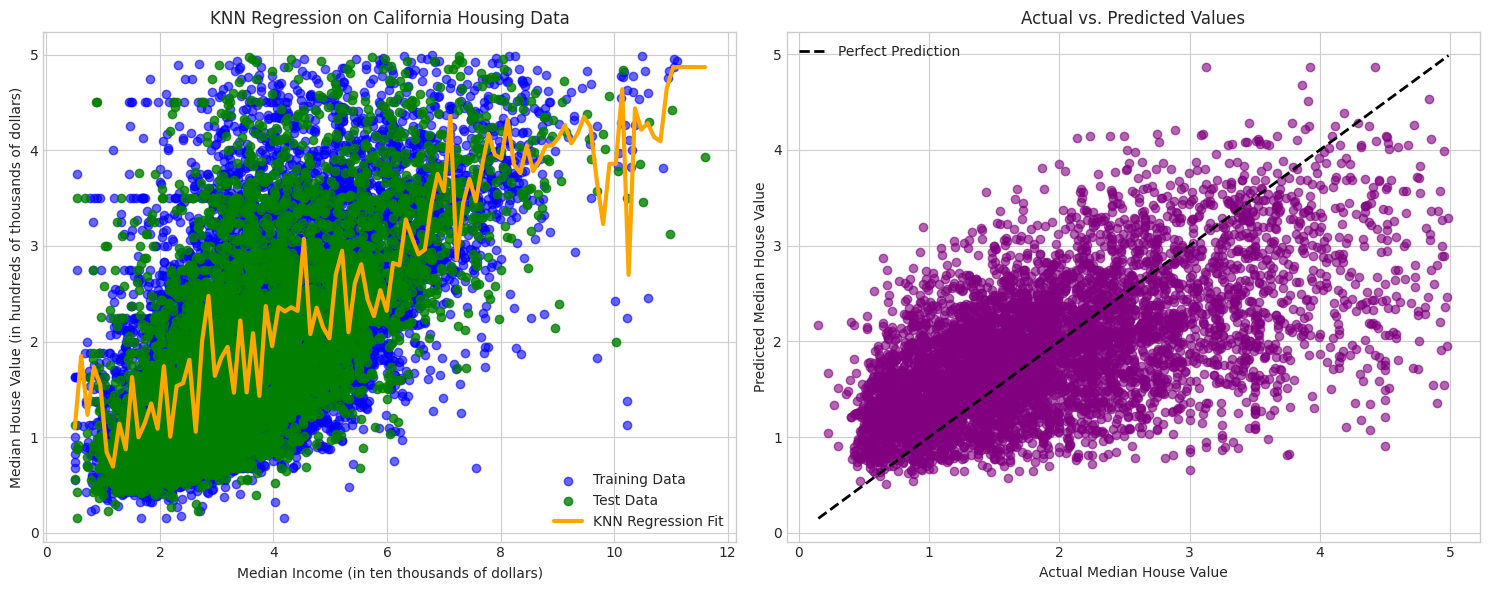

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error
from sklearn.datasets import fetch_california_housing
import warnings
warnings.filterwarnings('ignore') # <- Note: Don't use this, this is only for this notebook

# --- Dataset Setup ---
# Load the California Housing dataset
california_housing = fetch_california_housing(as_frame=True)
X = california_housing.frame[['MedInc']] # Using 'MedInc' (Median Income)
y = california_housing.target

# --- Data Cleaning ---
# 1. Remove rows where the target variable is truncated (equal to 5.0).
mask = y < 5.0
X_cleaned = X[mask]
y_cleaned = y[mask]

# 2. Remove extreme outliers based on median income.
# This helps the model focus on the main distribution.
# For example, filter out any income > 12.0
outlier_mask = X_cleaned['MedInc'] < 12.0
X_cleaned = X_cleaned[outlier_mask]
y_cleaned = y_cleaned[outlier_mask]

# Split the cleaned data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_cleaned, y_cleaned, test_size=0.3, random_state=42)

# --- Model Building ---
# Create and train the KNN Regressor model
# We choose n_neighbors=5, a common starting point
knn_regressor = KNeighborsRegressor(n_neighbors=5)
knn_regressor.fit(X_train, y_train)

# Make predictions on the test set
y_pred = knn_regressor.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")

# --- Plotting ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
plt.style.use('seaborn-v0_8-whitegrid')

# --- Plot 1: Regression Curve ---
# Generate predictions on a continuous range of X values to plot the regression curve
X_range = np.linspace(X_cleaned.min(), X_cleaned.max(), 100).reshape(-1, 1)
y_range_pred = knn_regressor.predict(X_range)

# Plot the training data points
ax1.scatter(X_train, y_train, color='blue', label='Training Data', alpha=0.6)

# Plot the testing data points
ax1.scatter(X_test, y_test, color='green', label='Test Data', alpha=0.8)

# Plot the KNN regression curve
ax1.plot(X_range, y_range_pred, color='orange', linewidth=3, label='KNN Regression Fit')

ax1.set_title("KNN Regression on California Housing Data")
ax1.set_xlabel("Median Income (in ten thousands of dollars)")
ax1.set_ylabel("Median House Value (in hundreds of thousands of dollars)")
ax1.legend()
ax1.grid(True)

# --- Plot 2: Actual vs. Predicted Values ---
ax2.scatter(y_test, y_pred, color='purple', alpha=0.6)
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Perfect Prediction')

ax2.set_title("Actual vs. Predicted Values")
ax2.set_xlabel("Actual Median House Value")
ax2.set_ylabel("Predicted Median House Value")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


- **Non-Linear Fit**: The orange line represents the KNN regression model's predictions. 
    - Unlike a straight linear regression line, this line is non-linear and jagged. 
    - This demonstrates the core principle of KNN regression: it is a non-parametric model that adapts to local data patterns rather than fitting a simple global function. 
    - Local Averaging: The jagged nature of the orange line shows how the model predicts the house value for a new data point by averaging the values of its k nearest neighbors. 
        - The line's curve changes with local density and distribution of the training data points.
- **Effect of Outliers**: The sharp fluctuations in the orange line, especially at the higher median income range, are due to the presence of outliers or sparse data. 
- **Data Density**: The plot visually highlights the density of the data. The majority of the data points are clustered in the median income range of 2 to 6, which is where the orange line appears smoother.

---
## 4. Gaussian Naive Bayes
- Gaussian Naive Bayes is a **probabilistic classifier** based on **Bayes' theorem**. 
- It assumes that features are **conditionally independent** given the class. 
- It models the distribution of continuous features for each class as a **Gaussian (normal) distribution**, making it suitable for continuous data.
- **Numerical Equation:**
    - Based on Bayes' theorem, the probability of a class $y$ given features $x_1, ..., x_n$ is:
    - $P(y|x\_1, ..., x\_n) = \frac{P(y) \prod_{i=1}^{n} P(x_i|y)}{P(x_1, ..., x_n)}$
    - The term $P(x\_i|y)$ is calculated using the Gaussian probability density function:
    - $P(x\_i|y=c) = \frac{1}{\sqrt{2\pi\sigma_c^2}} \exp\left(-\frac{(x_i - \mu_c)^2}{2\sigma_c^2}\right)$
    where $\mu_c$ and $\sigma_c^2$ are the mean and variance of feature $i$ for class $c$, respectively.
- **Pseudocode:**
    ```
    Function GaussianNB_Train(X_train, y_train):
        classes = unique(y_train)
        For each class c in classes:
            // Separate data by class
            X_c = X_train[y_train == c]
            
            // Calculate class prior probability
            class_priors[c] = count(X_c) / count(X_train)
            
            // Calculate mean and variance for each feature in this class
            For each feature j:
                mean[c][j] = mean(X_c[:, j])
                variance[c][j] = variance(X_c[:, j])
                
        Return class_priors, mean, variance

    Function GaussianNB_Predict(X_test, priors, means, variances):
        predictions = []
        For each test_point in X_test:
            posteriors = {}
            For each class c:
                // Initialize with prior probability
                posterior = priors[c]
                
                // Multiply by conditional probabilities
                For each feature j:
                    mu_c = means[c][j]
                    sigma2_c = variances[c][j]
                    
                    // Use Gaussian PDF formula
                    probability_x_given_c = calculate_gaussian_pdf(test_point[j], mu_c, sigma2_c)
                    posterior *= probability_x_given_c
                    
                posteriors[c] = posterior

            // Choose class with highest posterior probability
            predicted_class = argmax(posteriors)
            predictions.append(predicted_class)
            
        Return predictions
    ```

- The code will have the model trained on all 4 features (petal length, petal width, sepal length, sepal width).
- The plot to show decision boundary and predicted vs actual will only use petal length and petal width.

Training the Gaussian Naive Bayes model on ALL FOUR features...
Training complete.



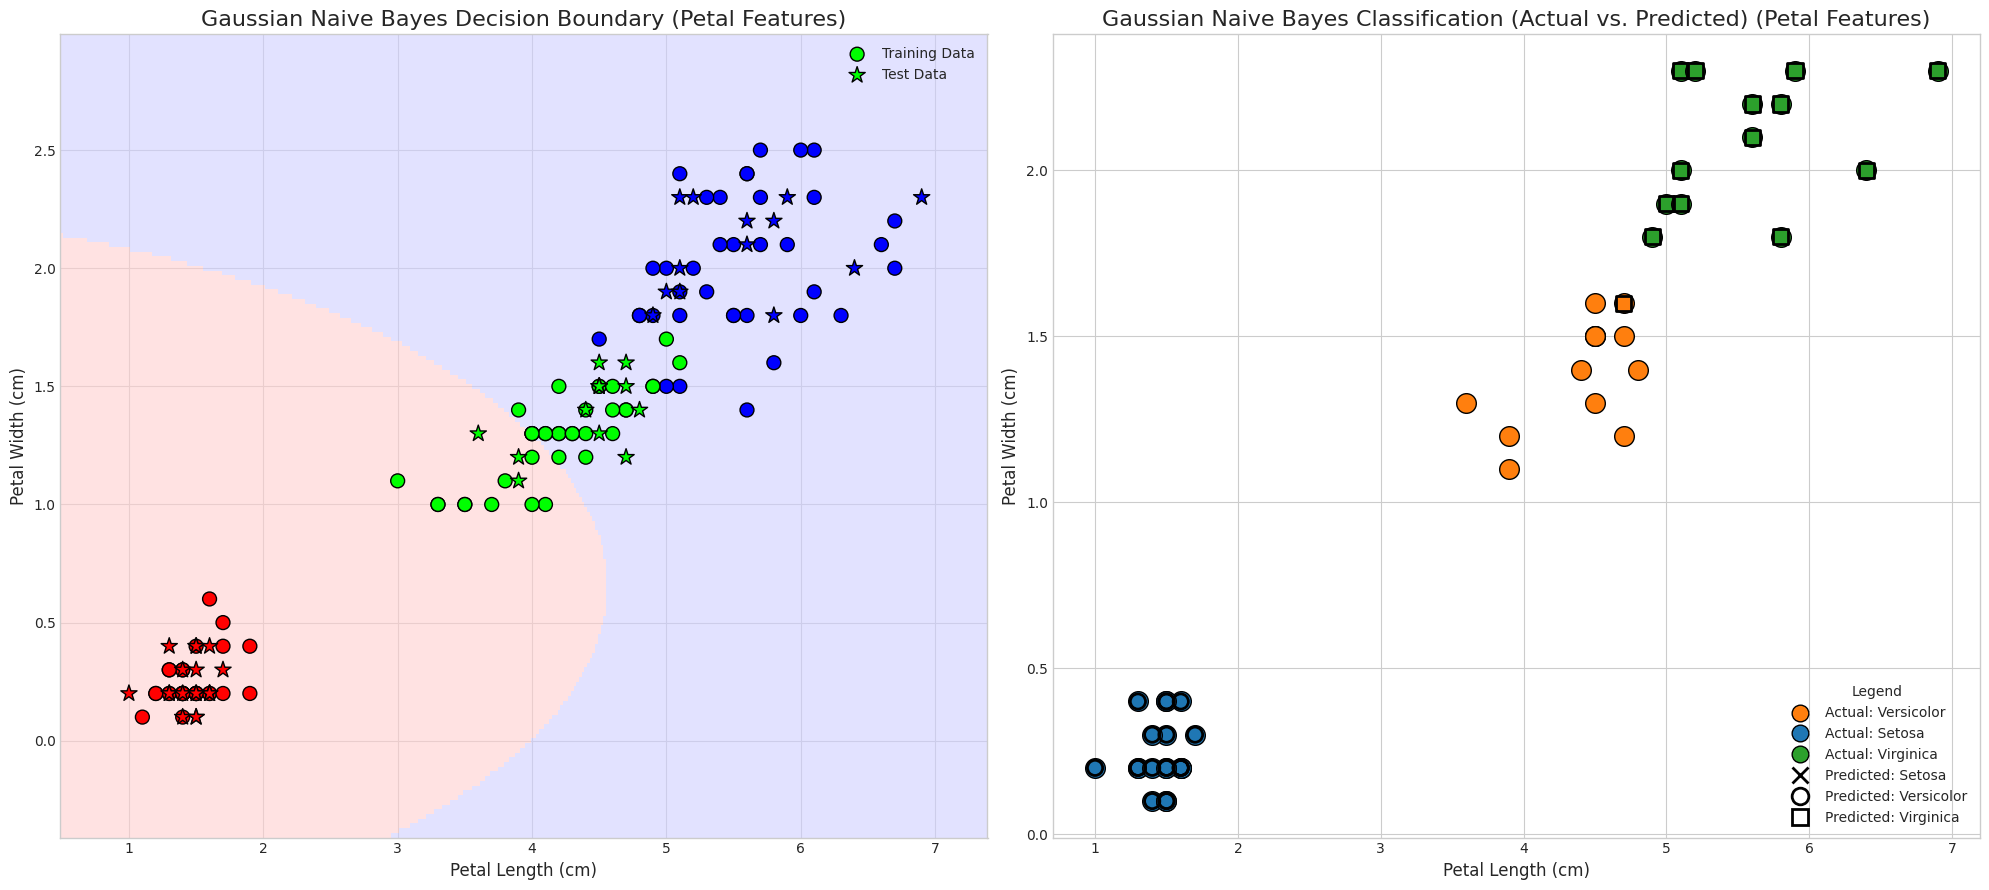


--- Classification Report (Model Trained on ALL Four Features) ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      0.92      0.96        13
   virginica       0.93      1.00      0.96        13

    accuracy                           0.98        45
   macro avg       0.98      0.97      0.97        45
weighted avg       0.98      0.98      0.98        45



In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.datasets import load_iris
import seaborn as sns

# --- Dataset setup ---
# We load the Iris dataset and use all four features for the model.
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names

# The features for visualization will be a subset of the full dataset
# We'll use petal length and petal width as they provide the best separation
X_plot = iris.data[:, 2:4]
feature_names_plot = ['petal length (cm)', 'petal width (cm)']

# Split the full dataset for training and testing the model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Get the corresponding test data for plotting
X_test_plot = X_test[:, 2:4]

# --- Model Building ---
# Initialize and train a single Gaussian Naive Bayes model on all four features.
gnb = GaussianNB()

print("Training the Gaussian Naive Bayes model on ALL FOUR features...")
gnb.fit(X_train, y_train)
print("Training complete.\n")

# Make predictions on the test set (using all four features)
y_pred = gnb.predict(X_test)

# --- Plotting Both Graphs ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9))

# --- Graph 1: Decision Boundary Plot ---
# We'll use the trained model on a 2D meshgrid
cmap_light = ListedColormap(['#FFCFCF', '#CFFFCF', '#CFCFFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

x_min, x_max = X_plot[:, 0].min() - 0.5, X_plot[:, 0].max() + 0.5
y_min, y_max = X_plot[:, 1].min() - 0.5, X_plot[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Use a dummy array with zeros for the two unused features (sepal features)
dummy_features = np.zeros((xx.ravel().shape[0], 2))

# Combine the meshgrid with the dummy features to form a 4D input for prediction
X_mesh_4d = np.c_[dummy_features, xx.ravel(), yy.ravel()]
Z = gnb.predict(X_mesh_4d)
Z = Z.reshape(xx.shape)

ax1.pcolormesh(xx, yy, Z, cmap=cmap_light, shading='auto', alpha=0.6)

# Plot the training and test data on the 2D plot
ax1.scatter(X_train[:, 2], X_train[:, 3], c=y_train, cmap=cmap_bold,
            edgecolor='k', s=100, label='Training Data')
ax1.scatter(X_test_plot[:, 0], X_test_plot[:, 1], c=y_test, cmap=cmap_bold,
            marker='*', edgecolor='k', s=150, label='Test Data')

ax1.set_title("Gaussian Naive Bayes Decision Boundary (Petal Features)", fontsize=16)
ax1.set_xlabel("Petal Length (cm)", fontsize=12)
ax1.set_ylabel("Petal Width (cm)", fontsize=12)
ax1.legend(loc='upper right')
ax1.grid(True)

# --- Graph 2: Actual vs. Predicted Plot ---
results_df = pd.DataFrame(X_test_plot, columns=feature_names_plot)
results_df['Actual Species'] = y_test
results_df['Predicted Species'] = y_pred

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
markers = ['o', 'x', 's']

for i, species_name in enumerate(iris.target_names):
    actual_indices = np.where(results_df['Actual Species'] == i)
    predicted_indices = np.where(results_df['Predicted Species'] == i)

    ax2.scatter(results_df.loc[actual_indices, feature_names_plot[0]],
                results_df.loc[actual_indices, feature_names_plot[1]],
                color=colors[i],
                marker='o',
                s=200,
                edgecolor='k',
                label=f'Actual: {species_name}')

    ax2.scatter(results_df.loc[predicted_indices, feature_names_plot[0]],
                results_df.loc[predicted_indices, feature_names_plot[1]],
                facecolors='none',
                edgecolor='k',
                marker=markers[i],
                s=120,
                linewidth=2,
                label=f'Predicted: {species_name}')

ax2.set_title('Gaussian Naive Bayes Classification (Actual vs. Predicted) (Petal Features)', fontsize=16)
ax2.set_xlabel('Petal Length (cm)', fontsize=12)
ax2.set_ylabel('Petal Width (cm)', fontsize=12)

legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label='Actual: Versicolor',
               markerfacecolor=colors[1], markersize=12, markeredgecolor='k'),
    plt.Line2D([0], [0], marker='o', color='w', label='Actual: Setosa',
               markerfacecolor=colors[0], markersize=12, markeredgecolor='k'),
    plt.Line2D([0], [0], marker='o', color='w', label='Actual: Virginica',
               markerfacecolor=colors[2], markersize=12, markeredgecolor='k'),
    plt.Line2D([0], [0], marker='x', color='k', linestyle='None',
               label='Predicted: Setosa', markersize=12, markeredgewidth=2),
    plt.Line2D([0], [0], marker='o', color='k', linestyle='None',
               label='Predicted: Versicolor', markersize=12, markeredgewidth=2, fillstyle='none'),
    plt.Line2D([0], [0], marker='s', color='k', linestyle='None',
               label='Predicted: Virginica', markersize=12, markeredgewidth=2, fillstyle='none')
]

ax2.legend(handles=legend_elements, title='Legend', loc='lower right', fontsize=10)
ax2.grid(True)

plt.tight_layout()
plt.show()

# --- Print Classification Report ---
print("\n--- Classification Report (Model Trained on ALL Four Features) ---")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

---
# Optimization Algorithms
- This section describes a general-purpose optimization algorithm used to train many machine learning models.


## 1. Stochastic Gradient Descent (SGD)
- SGD is an iterative **optimization algorithm** used to minimize a loss function. 
- Unlike standard Gradient Descent, which uses the entire dataset to compute the gradient, SGD updates model parameters using the gradient from a **single, randomly chosen training example** (or a small batch). This makes it computationally efficient and well-suited for large datasets.

- **Numerical Equation:**
- The update rule for a parameter $\theta$ is:
- $\theta_{new} = \theta_{old} - \eta \cdot \nabla L(x_i, y_i; \theta_{old})$
  - $\eta$ is the **learning rate**.
  - $\nabla L(x_i, y_i; \theta_{old})$ is the gradient of the loss function $L$ with respect to the parameters, calculated on a **single random data point** $(x_i, y_i)$.

- **Pseudocode:**
  ```
  Function SGD(model, loss_function, learning_rate, epochs, X_train, y_train):
      Initialize model parameters (weights, biases) randomly
      For epoch from 1 to epochs:
          Shuffle the training data
          For each training example (x, y) in the shuffled data:
              // Compute the loss and its gradient for this single example
              gradient = compute_gradient(loss_function, model, x, y)
              
              // Update the model parameters
              model.parameters = model.parameters - learning_rate * gradient
      Return model
  ```



Mean Squared Error: 0.54


/home/troll/miniconda3/envs/random/lib/python3.12/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but SGDRegressor was fitted with feature names
  warnings.warn(


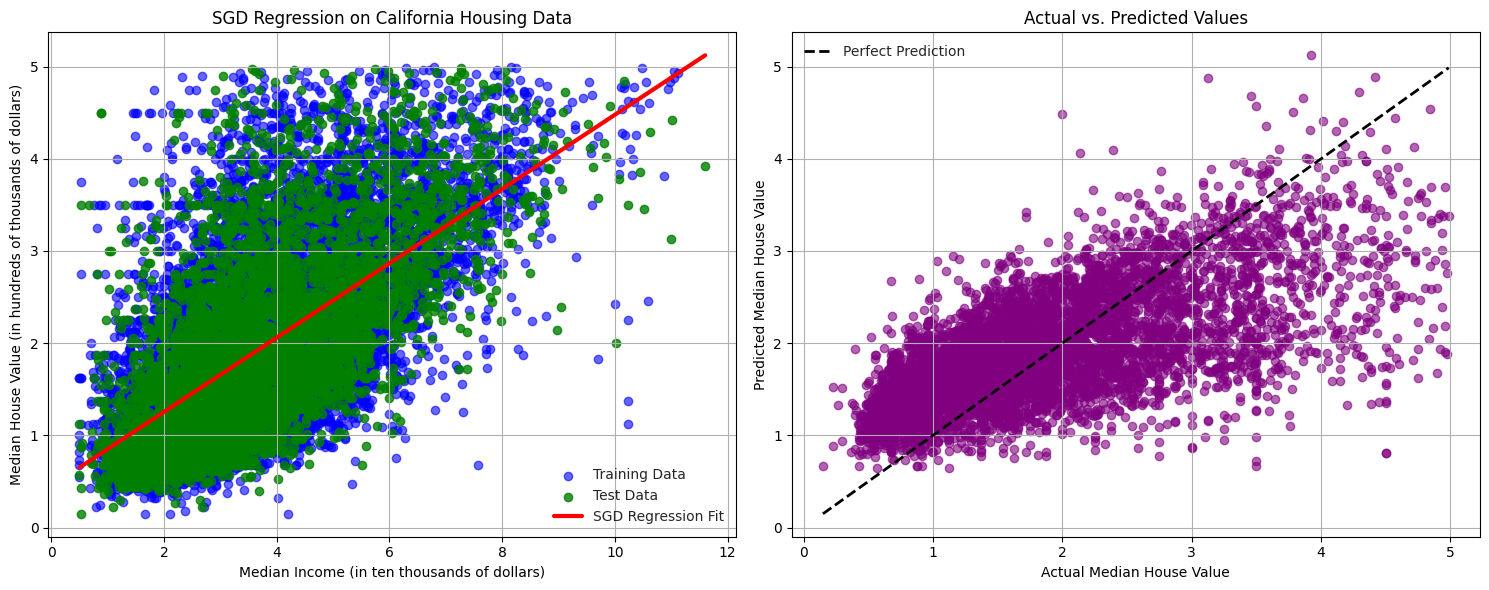

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error
from sklearn.datasets import fetch_california_housing

# --- Dataset Setup ---
# Load the California Housing dataset
california_housing = fetch_california_housing(as_frame=True)
X = california_housing.frame[['MedInc']] # Using 'MedInc' (Median Income)
y = california_housing.target

# --- Data Cleaning ---
# 1. Remove rows where the target variable is truncated (equal to 5.0).
mask = y < 5.0
X_cleaned = X[mask]
y_cleaned = y[mask]

# 2. Remove extreme outliers based on median income.
outlier_mask = X_cleaned['MedInc'] < 12.0
X_cleaned = X_cleaned[outlier_mask]
y_cleaned = y_cleaned[outlier_mask]

# Split the cleaned data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_cleaned, y_cleaned, test_size=0.3, random_state=42)

# --- Model Building ---
# Create and train the SGD Regressor model
sgd_regressor = SGDRegressor(max_iter=1000, tol=1e-3, eta0=0.01)
sgd_regressor.fit(X_train, y_train)

# Make predictions on the test set
y_pred = sgd_regressor.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")

# --- Plotting ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
plt.style.use('seaborn-v0_8-whitegrid')

# --- Plot 1: Regression Curve ---
# Generate predictions on a continuous range of X values to plot the regression curve
X_range = np.linspace(X_cleaned.min(), X_cleaned.max(), 100).reshape(-1, 1)
y_range_pred = sgd_regressor.predict(X_range)

# Plot the training data points
ax1.scatter(X_train, y_train, color='blue', label='Training Data', alpha=0.6)

# Plot the testing data points
ax1.scatter(X_test, y_test, color='green', label='Test Data', alpha=0.8)

# Plot the SGD regression curve
ax1.plot(X_range, y_range_pred, color='red', linewidth=3, label='SGD Regression Fit')

ax1.set_title("SGD Regression on California Housing Data")
ax1.set_xlabel("Median Income (in ten thousands of dollars)")
ax1.set_ylabel("Median House Value (in hundreds of thousands of dollars)")
ax1.legend()
ax1.grid(True)

# --- Plot 2: Actual vs. Predicted Values ---
ax2.scatter(y_test, y_pred, color='purple', alpha=0.6)
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Perfect Prediction')

ax2.set_title("Actual vs. Predicted Values")
ax2.set_xlabel("Actual Median House Value")
ax2.set_ylabel("Predicted Median House Value")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

---
# Ensemble Models
- This section focuses on models that combine multiple weak learners to create a more powerful and robust final model.

## 1. Random Forest 
- Random Forest is an ensemble learning method that builds a multitude of decision trees at training time. 
- It reduces overfitting and improves accuracy by introducing two sources of randomness: bootstrap aggregating (bagging), where each tree is trained on a random sample of the data with replacement, and feature randomness, where each tree considers only a random subset of features for splitting. 
- The final prediction is an average (regression) or a majority vote (classification) of the individual tree predictions.
- Regression & Classification based on which metric model is used.
- **Numerical Equation:**
    - The final prediction $\hat{y}$ is the average of the predictions of $B$ trees:
    - $\hat{y} = \frac{1}{B} \sum_{b=1}^{B} f_b(x)$
        - $f_b(x)$ is the prediction of the $b^{th}$ decision tree.
- **Pseudocode:**
    ```
    Function RandomForest_Train(X_train, y_train, num_trees, num_features_per_split):
        forest = []
        For b from 1 to num_trees:
            // 1. Create a bootstrap sample of the data
            bootstrap_sample_X, bootstrap_sample_y = get_bootstrap_sample(X_train, y_train)
            
            // 2. Train a decision tree on this sample
            tree = train_decision_tree(bootstrap_sample_X, bootstrap_sample_y, num_features_per_split)
            
            // 3. Add the trained tree to the forest
            forest.append(tree)
        Return forest

    Function RandomForest_Predict(forest, X_test):
        predictions = []
        For each test_point in X_test:
            tree_predictions = []
            For each tree in forest:
                tree_predictions.append(tree.predict(test_point))
                
            // For classification, return the majority vote
            final_prediction = majority_vote(tree_predictions)
            predictions.append(final_prediction)
            
        Return predictions
    ```



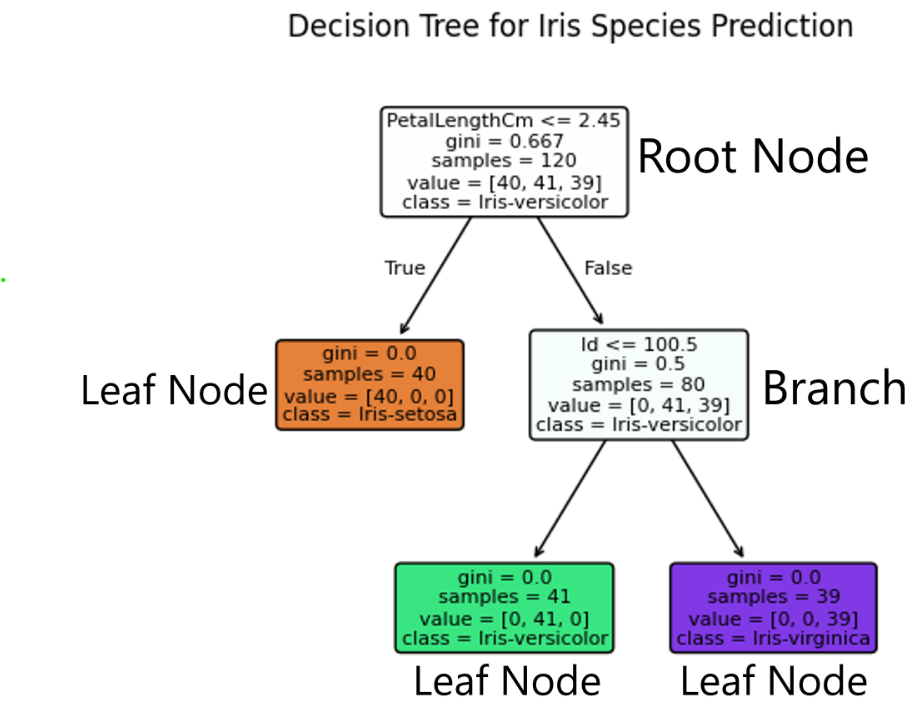

### Random Forest for Classification

- The code will have the model trained on all 4 features (petal length, petal width, sepal length, sepal width).
- The plot to show decision boundary and predicted vs actual will only use petal length and petal width.

Training the Random Forest model on ALL FOUR features...
Training complete.



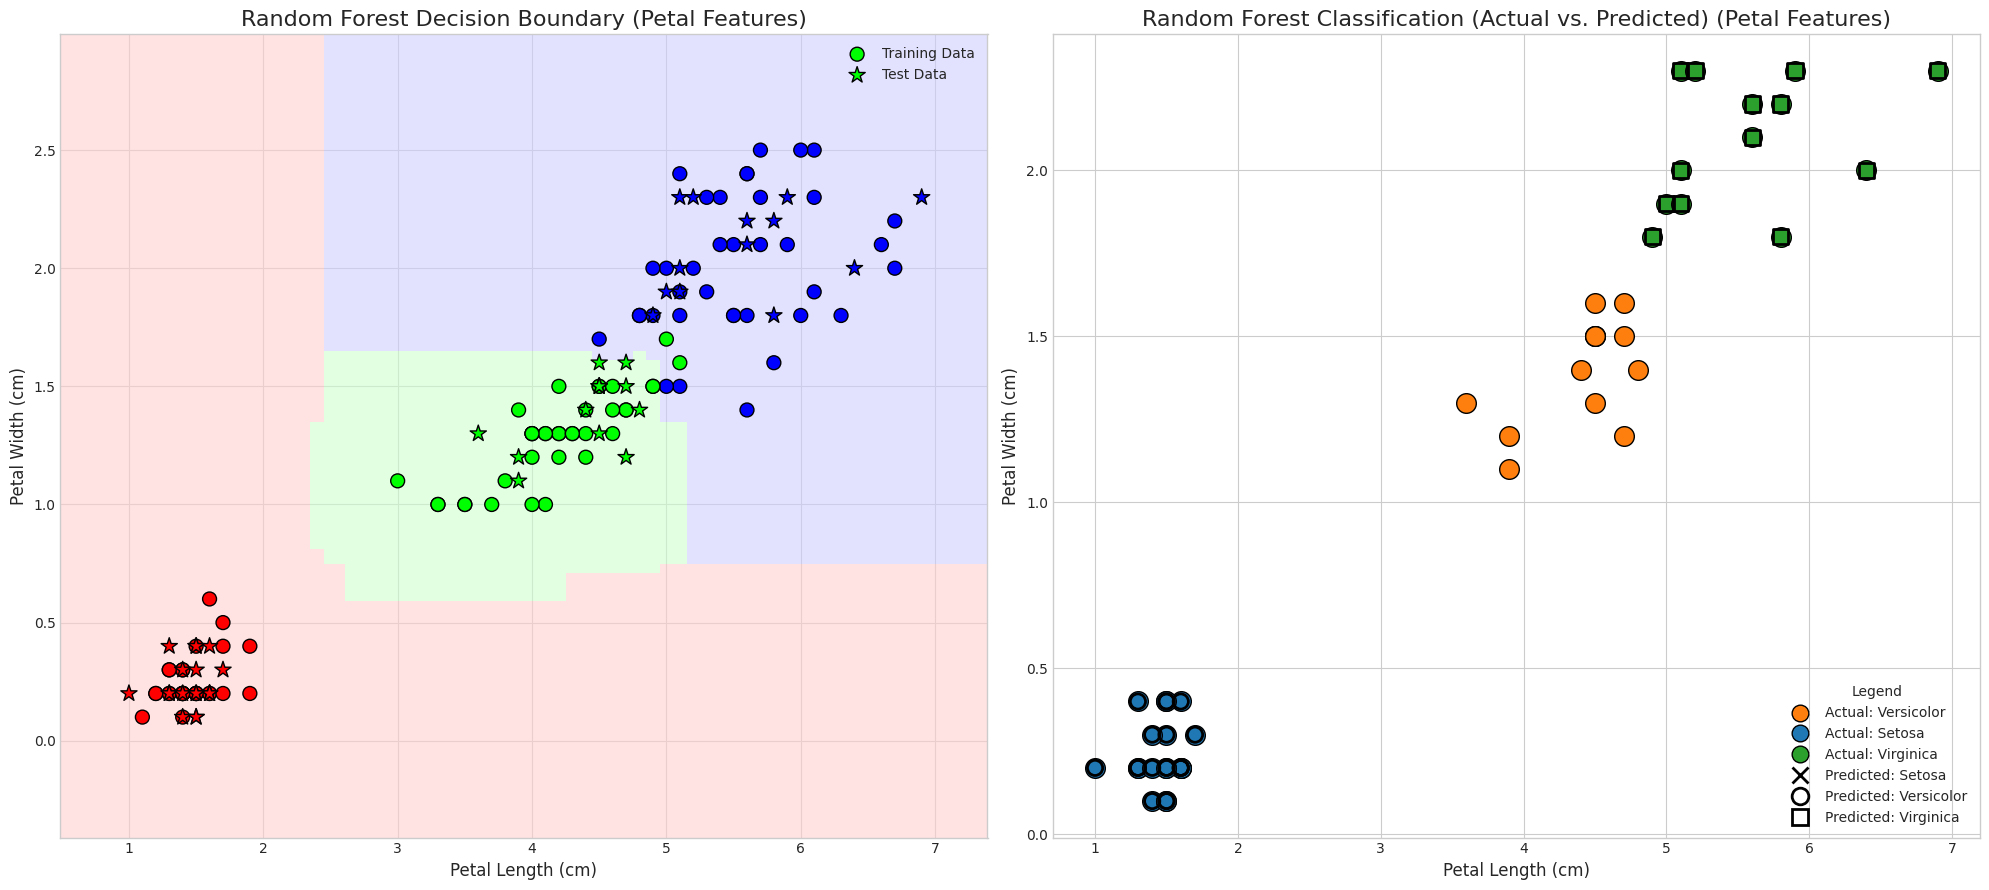


--- Classification Report (Model Trained on ALL Four Features) ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.datasets import load_iris

# --- Dataset setup ---
# We load the Iris dataset and use all four features for the model.
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names

# The features for visualization will be a subset of the full dataset
# We'll use petal length and petal width as they provide the best separation
X_plot = iris.data[:, 2:4]
feature_names_plot = ['petal length (cm)', 'petal width (cm)']

# Split the full dataset for training and testing the model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Get the corresponding test data for plotting
X_test_plot = X_test[:, 2:4] 

# --- Model Building ---
# Initialize and train a single Random Forest model on all four features.
rfc = RandomForestClassifier(n_estimators=100, random_state=42)

print("Training the Random Forest model on ALL FOUR features...")
rfc.fit(X_train, y_train)
print("Training complete.\n")

# Make predictions on the test set (using all four features)
y_pred = rfc.predict(X_test)

# --- Plotting Both Graphs ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9))

# --- Graph 1: Decision Boundary Plot ---
# We'll use the trained model on a 2D meshgrid
cmap_light = ListedColormap(['#FFCFCF', '#CFFFCF', '#CFCFFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

x_min, x_max = X_plot[:, 0].min() - 0.5, X_plot[:, 0].max() + 0.5
y_min, y_max = X_plot[:, 1].min() - 0.5, X_plot[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Use a dummy array with zeros for the two unused features (sepal features)
dummy_features = np.zeros((xx.ravel().shape[0], 2))

# Combine the meshgrid with the dummy features to form a 4D input for prediction
X_mesh_4d = np.c_[dummy_features, xx.ravel(), yy.ravel()]
Z = rfc.predict(X_mesh_4d)
Z = Z.reshape(xx.shape)

ax1.pcolormesh(xx, yy, Z, cmap=cmap_light, shading='auto', alpha=0.6)

# Plot the training and test data on the 2D plot
ax1.scatter(X_train[:, 2], X_train[:, 3], c=y_train, cmap=cmap_bold,
            edgecolor='k', s=100, label='Training Data')
ax1.scatter(X_test_plot[:, 0], X_test_plot[:, 1], c=y_test, cmap=cmap_bold,
            marker='*', edgecolor='k', s=150, label='Test Data')

ax1.set_title("Random Forest Decision Boundary (Petal Features)", fontsize=16)
ax1.set_xlabel("Petal Length (cm)", fontsize=12)
ax1.set_ylabel("Petal Width (cm)", fontsize=12)
ax1.legend(loc='upper right')
ax1.grid(True)

# --- Graph 2: Actual vs. Predicted Plot ---
results_df = pd.DataFrame(X_test_plot, columns=feature_names_plot)
results_df['Actual Species'] = y_test
results_df['Predicted Species'] = y_pred

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
markers = ['o', 'x', 's']

for i, species_name in enumerate(iris.target_names):
    actual_indices = np.where(results_df['Actual Species'] == i)
    predicted_indices = np.where(results_df['Predicted Species'] == i)

    ax2.scatter(results_df.loc[actual_indices, feature_names_plot[0]],
                results_df.loc[actual_indices, feature_names_plot[1]],
                color=colors[i],
                marker='o',
                s=200,
                edgecolor='k',
                label=f'Actual: {species_name}')

    ax2.scatter(results_df.loc[predicted_indices, feature_names_plot[0]],
                results_df.loc[predicted_indices, feature_names_plot[1]],
                facecolors='none',
                edgecolor='k',
                marker=markers[i],
                s=120,
                linewidth=2,
                label=f'Predicted: {species_name}')

ax2.set_title('Random Forest Classification (Actual vs. Predicted) (Petal Features)', fontsize=16)
ax2.set_xlabel('Petal Length (cm)', fontsize=12)
ax2.set_ylabel('Petal Width (cm)', fontsize=12)

legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label='Actual: Versicolor',
               markerfacecolor=colors[1], markersize=12, markeredgecolor='k'),
    plt.Line2D([0], [0], marker='o', color='w', label='Actual: Setosa',
               markerfacecolor=colors[0], markersize=12, markeredgecolor='k'),
    plt.Line2D([0], [0], marker='o', color='w', label='Actual: Virginica',
               markerfacecolor=colors[2], markersize=12, markeredgecolor='k'),
    plt.Line2D([0], [0], marker='x', color='k', linestyle='None',
               label='Predicted: Setosa', markersize=12, markeredgewidth=2),
    plt.Line2D([0], [0], marker='o', color='k', linestyle='None',
               label='Predicted: Versicolor', markersize=12, markeredgewidth=2, fillstyle='none'),
    plt.Line2D([0], [0], marker='s', color='k', linestyle='None',
               label='Predicted: Virginica', markersize=12, markeredgewidth=2, fillstyle='none')
]

ax2.legend(handles=legend_elements, title='Legend', loc='lower right', fontsize=10)
ax2.grid(True)

plt.tight_layout()
plt.show()

# --- Print Classification Report ---
print("\n--- Classification Report (Model Trained on ALL Four Features) ---")
print(classification_report(y_test, y_pred, target_names=iris.target_names))


### Random Forest for Regression

Mean Squared Error: 0.73


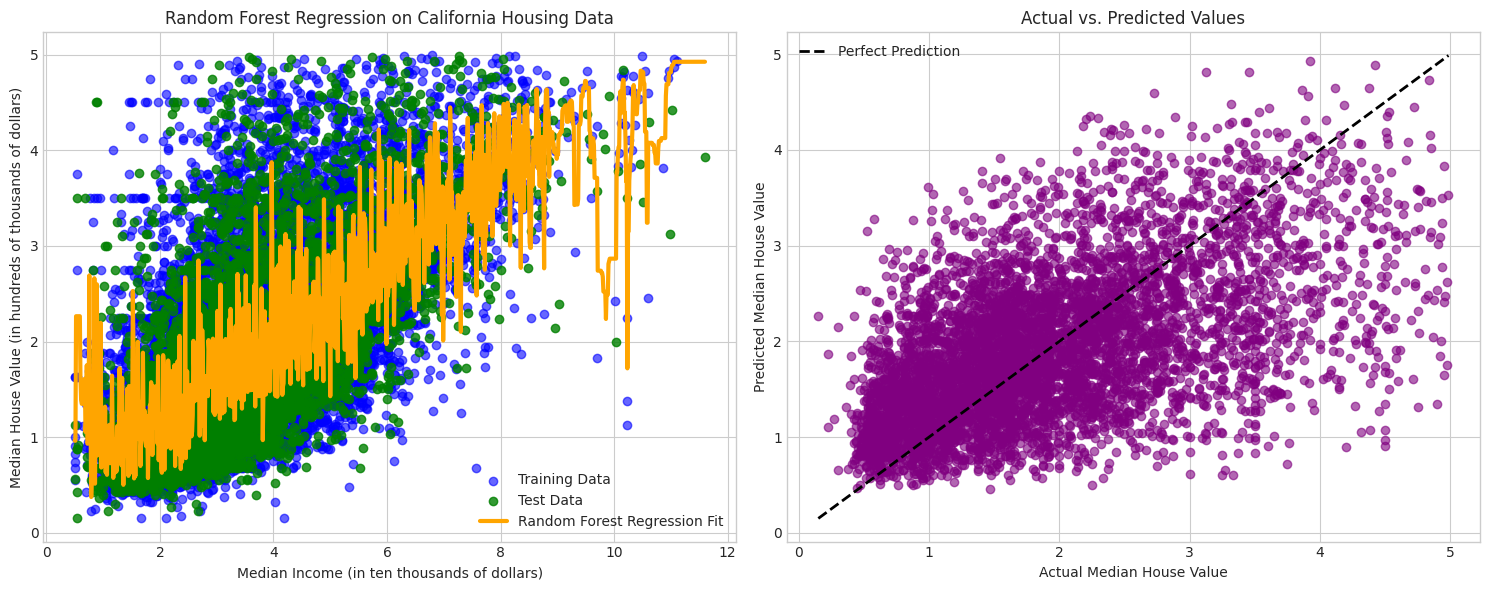

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.datasets import fetch_california_housing
import warnings
warnings.filterwarnings('ignore') # <- Note: Don't use this, this is only for this notebook

# --- Dataset Setup ---
# Load the California Housing dataset
california_housing = fetch_california_housing(as_frame=True)
X = california_housing.frame[['MedInc']]  # Using 'MedInc' (Median Income)
y = california_housing.target

# --- Data Cleaning ---
# 1. Remove rows where the target variable is truncated (equal to 5.0).
mask = y < 5.0
X_cleaned = X[mask]
y_cleaned = y[mask]

# 2. Remove extreme outliers based on median income.
# This helps the model focus on the main distribution.
# For example, filter out any income > 12.0
outlier_mask = X_cleaned['MedInc'] < 12.0
X_cleaned = X_cleaned[outlier_mask]
y_cleaned = y_cleaned[outlier_mask]

# Split the cleaned data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_cleaned, y_cleaned, test_size=0.3, random_state=42)

# --- Model Building ---
# Create and train the Random Forest Regressor model
rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
rf_regressor.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_regressor.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")

# --- Plotting ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
plt.style.use('seaborn-v0_8-whitegrid')

# --- Plot 1: Regression Curve ---
# Generate predictions on a continuous range of X values to plot the regression curve
X_range = np.linspace(X_cleaned.min(), X_cleaned.max(), 1000).reshape(-1, 1)
y_range_pred = rf_regressor.predict(X_range)

# Plot the training data points
ax1.scatter(X_train, y_train, color='blue', label='Training Data', alpha=0.6)

# Plot the testing data points
ax1.scatter(X_test, y_test, color='green', label='Test Data', alpha=0.8)

# Plot the Random Forest regression curve
ax1.plot(X_range, y_range_pred, color='orange', linewidth=3, label='Random Forest Regression Fit')

ax1.set_title("Random Forest Regression on California Housing Data")
ax1.set_xlabel("Median Income (in ten thousands of dollars)")
ax1.set_ylabel("Median House Value (in hundreds of thousands of dollars)")
ax1.legend()
ax1.grid(True)

# --- Plot 2: Actual vs. Predicted Values ---
ax2.scatter(y_test, y_pred, color='purple', alpha=0.6)
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Perfect Prediction')

ax2.set_title("Actual vs. Predicted Values")
ax2.set_xlabel("Actual Median House Value")
ax2.set_ylabel("Predicted Median House Value")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

---
## 2. Gradient Boost
- Gradient Boosting is an ensemble technique that builds a series of weak learners **sequentially**. 
- Each new learner is trained to **correct the errors of the preceding models**. 
- It does this by fitting the new model to the **pseudo-residuals**, which are the gradients of the loss function. 
- The process iteratively refines the model by focusing on the examples that are currently poorly predicted.
- **Numerical Equation:**
    - The prediction function is a sum of the predictions of all trees:
    - $F_m(x) = F_{m-1}(x) + \alpha h_m(x)$
        - $F_m(x)$ is the model's prediction at step $m$.
        - $F_{m-1}(x)$ is the prediction from the previous step.
        - $h_m(x)$ is the new weak learner (tree) trained on the residuals.
        - $\alpha$ is the **learning rate**.

- **Pseudocode:**
    ```
    Function GradientBoost_Train(X, y, num_trees, learning_rate):
        // Initialize F_0(x) with a constant value (e.g., mean of y)
        F_m = initial_prediction(y)
        
        For m from 1 to num_trees:
            // 1. Compute the pseudo-residuals (negative gradient of the loss function)
            residuals = -gradient(loss_function, y, F_m)
            
            // 2. Train a new weak learner (e.g., a decision tree) on the residuals
            h_m = train_decision_tree(X, residuals)
            
            // 3. Update the model
            F_m = F_m + learning_rate * h_m
            
        Return F_m
```


### Gradient Boost for Classifcation

- The code will have the model trained on all 4 features (petal length, petal width, sepal length, sepal width).
- The plot to show decision boundary and predicted vs actual will only use petal length and petal width.

Training the Gradient Boosting model on ALL FOUR features...
Training complete.



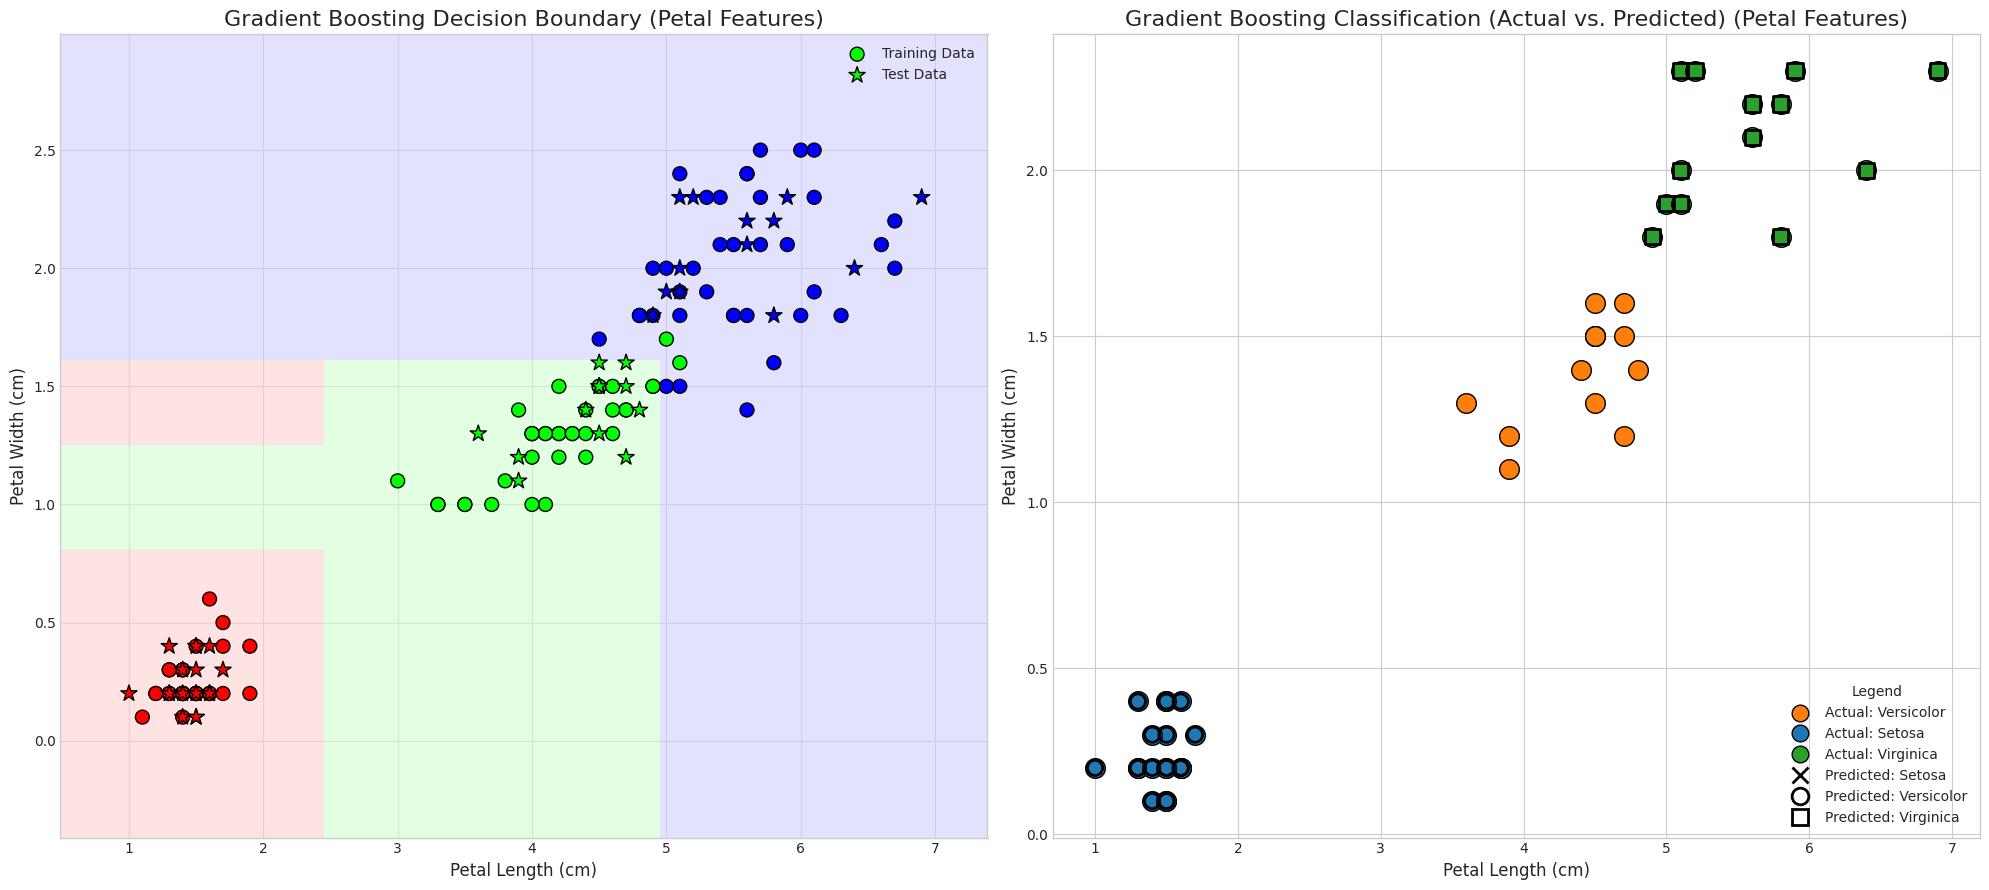


--- Classification Report (Model Trained on ALL Four Features) ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.datasets import load_iris

# --- Dataset setup ---
# We load the Iris dataset and use all four features for the model.
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names

# The features for visualization will be a subset of the full dataset
# We'll use petal length and petal width as they provide the best separation
X_plot = iris.data[:, 2:4]
feature_names_plot = ['petal length (cm)', 'petal width (cm)']

# Split the full dataset for training and testing the model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Get the corresponding test data for plotting
X_test_plot = X_test[:, 2:4]

# --- Model Building ---
# Initialize and train a single Gradient Boosting model on all four features.
gbc = GradientBoostingClassifier(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

print("Training the Gradient Boosting model on ALL FOUR features...")
gbc.fit(X_train, y_train)
print("Training complete.\n")

# Make predictions on the test set (using all four features)
y_pred = gbc.predict(X_test)

# --- Plotting Both Graphs ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9))

# --- Graph 1: Decision Boundary Plot ---
# We'll use the trained model on a 2D meshgrid
cmap_light = ListedColormap(['#FFCFCF', '#CFFFCF', '#CFCFFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

x_min, x_max = X_plot[:, 0].min() - 0.5, X_plot[:, 0].max() + 0.5
y_min, y_max = X_plot[:, 1].min() - 0.5, X_plot[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Use a dummy array with zero values for the two unused features (sepal features)
dummy_features = np.zeros((xx.ravel().shape[0], 2))

# Combine the meshgrid with the dummy features to form a 4D input for prediction
X_mesh_4d = np.c_[dummy_features, xx.ravel(), yy.ravel()]
Z = gbc.predict(X_mesh_4d)
Z = Z.reshape(xx.shape)

ax1.pcolormesh(xx, yy, Z, cmap=cmap_light, shading='auto', alpha=0.6)

# Plot the training and test data on the 2D plot
ax1.scatter(X_train[:, 2], X_train[:, 3], c=y_train, cmap=cmap_bold,
            edgecolor='k', s=100, label='Training Data')
ax1.scatter(X_test_plot[:, 0], X_test_plot[:, 1], c=y_test, cmap=cmap_bold,
            marker='*', edgecolor='k', s=150, label='Test Data')

ax1.set_title("Gradient Boosting Decision Boundary (Petal Features)", fontsize=16)
ax1.set_xlabel("Petal Length (cm)", fontsize=12)
ax1.set_ylabel("Petal Width (cm)", fontsize=12)
ax1.legend(loc='upper right')
ax1.grid(True)

# --- Graph 2: Actual vs. Predicted Plot ---
results_df = pd.DataFrame(X_test_plot, columns=feature_names_plot)
results_df['Actual Species'] = y_test
results_df['Predicted Species'] = y_pred

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
markers = ['o', 'x', 's']

for i, species_name in enumerate(iris.target_names):
    actual_indices = np.where(results_df['Actual Species'] == i)
    predicted_indices = np.where(results_df['Predicted Species'] == i)

    ax2.scatter(results_df.loc[actual_indices, feature_names_plot[0]],
                results_df.loc[actual_indices, feature_names_plot[1]],
                color=colors[i],
                marker='o',
                s=200,
                edgecolor='k',
                label=f'Actual: {species_name}')

    ax2.scatter(results_df.loc[predicted_indices, feature_names_plot[0]],
                results_df.loc[predicted_indices, feature_names_plot[1]],
                facecolors='none',
                edgecolor='k',
                marker=markers[i],
                s=120,
                linewidth=2,
                label=f'Predicted: {species_name}')

ax2.set_title('Gradient Boosting Classification (Actual vs. Predicted) (Petal Features)', fontsize=16)
ax2.set_xlabel('Petal Length (cm)', fontsize=12)
ax2.set_ylabel('Petal Width (cm)', fontsize=12)

legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label='Actual: Versicolor',
               markerfacecolor=colors[1], markersize=12, markeredgecolor='k'),
    plt.Line2D([0], [0], marker='o', color='w', label='Actual: Setosa',
               markerfacecolor=colors[0], markersize=12, markeredgecolor='k'),
    plt.Line2D([0], [0], marker='o', color='w', label='Actual: Virginica',
               markerfacecolor=colors[2], markersize=12, markeredgecolor='k'),
    plt.Line2D([0], [0], marker='x', color='k', linestyle='None',
               label='Predicted: Setosa', markersize=12, markeredgewidth=2),
    plt.Line2D([0], [0], marker='o', color='k', linestyle='None',
               label='Predicted: Versicolor', markersize=12, markeredgewidth=2, fillstyle='none'),
    plt.Line2D([0], [0], marker='s', color='k', linestyle='None',
               label='Predicted: Virginica', markersize=12, markeredgewidth=2, fillstyle='none')
]

ax2.legend(handles=legend_elements, title='Legend', loc='lower right', fontsize=10)
ax2.grid(True)

plt.tight_layout()
plt.show()

# --- Print Classification Report ---
print("\n--- Classification Report (Model Trained on ALL Four Features) ---")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

### Gradient Boost for Regression

Mean Squared Error: 0.54


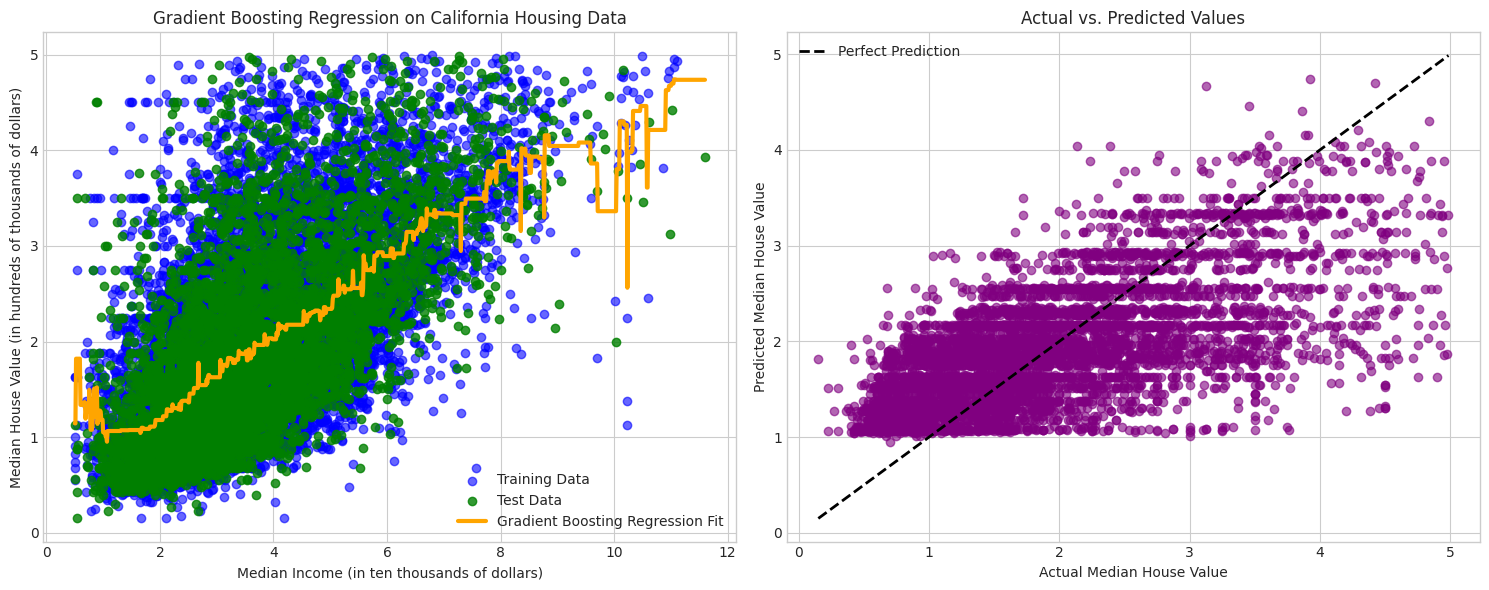

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error
from sklearn.datasets import fetch_california_housing
import warnings
warnings.filterwarnings('ignore') # <- Note: Don't use this, this is only for this notebook

# --- Dataset Setup ---
# Load the California Housing dataset
california_housing = fetch_california_housing(as_frame=True)
X = california_housing.frame[['MedInc']]  # Using 'MedInc' (Median Income)
y = california_housing.target

# --- Data Cleaning ---
# 1. Remove rows where the target variable is truncated (equal to 5.0).
mask = y < 5.0
X_cleaned = X[mask]
y_cleaned = y[mask]

# 2. Remove extreme outliers based on median income.
# This helps the model focus on the main distribution.
# For example, filter out any income > 12.0
outlier_mask = X_cleaned['MedInc'] < 12.0
X_cleaned = X_cleaned[outlier_mask]
y_cleaned = y_cleaned[outlier_mask]

# Split the cleaned data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_cleaned, y_cleaned, test_size=0.3, random_state=42)

# --- Model Building ---
# Create and train the Gradient Boosting Regressor model
gb_regressor = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
gb_regressor.fit(X_train, y_train)

# Make predictions on the test set
y_pred = gb_regressor.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")

# --- Plotting ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
plt.style.use('seaborn-v0_8-whitegrid')

# --- Plot 1: Regression Curve ---
# Generate predictions on a continuous range of X values to plot the regression curve
X_range = np.linspace(X_cleaned.min(), X_cleaned.max(), 1000).reshape(-1, 1)
y_range_pred = gb_regressor.predict(X_range)

# Plot the training data points
ax1.scatter(X_train, y_train, color='blue', label='Training Data', alpha=0.6)

# Plot the testing data points
ax1.scatter(X_test, y_test, color='green', label='Test Data', alpha=0.8)

# Plot the Gradient Boosting regression curve
ax1.plot(X_range, y_range_pred, color='orange', linewidth=3, label='Gradient Boosting Regression Fit')

ax1.set_title("Gradient Boosting Regression on California Housing Data")
ax1.set_xlabel("Median Income (in ten thousands of dollars)")
ax1.set_ylabel("Median House Value (in hundreds of thousands of dollars)")
ax1.legend()
ax1.grid(True)

# --- Plot 2: Actual vs. Predicted Values ---
ax2.scatter(y_test, y_pred, color='purple', alpha=0.6)
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Perfect Prediction')

ax2.set_title("Actual vs. Predicted Values")
ax2.set_xlabel("Actual Median House Value")
ax2.set_ylabel("Predicted Median House Value")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

---
## 3. XGBoost (Extreme Gradient Boosting)
- XGBoost is a highly optimized and scalable implementation of gradient boosting. 
- It improves upon the basic framework with several key features: 
    - **L1 and L2 regularization** to prevent overfitting, 
    - a more efficient **tree pruning algorithm**, 
    - a sophisticated method for handling **missing values**, and 
    - parallelization of tree construction.
- **Numerical Equation:**
    - The objective function to be minimized at each step $t$ is:
    - $\mathcal{L}^{(t)} = \sum_{i=1}^{n} l(y_i, \hat{y}*i^{(t-1)} + f_t(x_i)) + \Omega(f_t)$
        - $\Omega(f_t)$ is the **regularization term**:
        - $\Omega(f_t) = \gamma T + \frac{1}{2} \lambda \sum*{j=1}^{T} w_j^2$
        - $l$ is the loss function.
        - $f_t(x_i)$ is the new tree.
        - $T$ is the number of leaves in the tree.
        - $w_j$ is the weight of leaf $j$.
        - $\gamma$ and $\lambda$ are regularization parameters.
- **Pseudocode:**
    ```
    Function XGBoost_Train(X, y, num_trees, learning_rate, gamma, lambda):
        // Initialize F_0 with a constant value
        F_m = initial_prediction(y)
        
        For m from 1 to num_trees:
            // 1. Compute first and second order gradients of the loss function
            g = gradient_1(loss, y, F_m)
            h = gradient_2(loss, y, F_m)
            
            // 2. Build a new tree f_m
            // This process involves finding the best splits using the calculated gradients (g, h)
            // and a similarity score that includes the regularization terms (gamma, lambda)
            f_m = build_xgboost_tree(X, g, h, gamma, lambda)
            
            // 3. Update the model
            F_m = F_m + learning_rate * f_m
            
        Return F_m
    ```


### Extreme Gradient Boost for Classification

- The code will have the model trained on all 4 features (petal length, petal width, sepal length, sepal width).
- The plot to show decision boundary and predicted vs actual will only use petal length and petal width.

In [8]:
!pip install xgboost

Training the XGBoost model on ALL FOUR features...
Training complete.



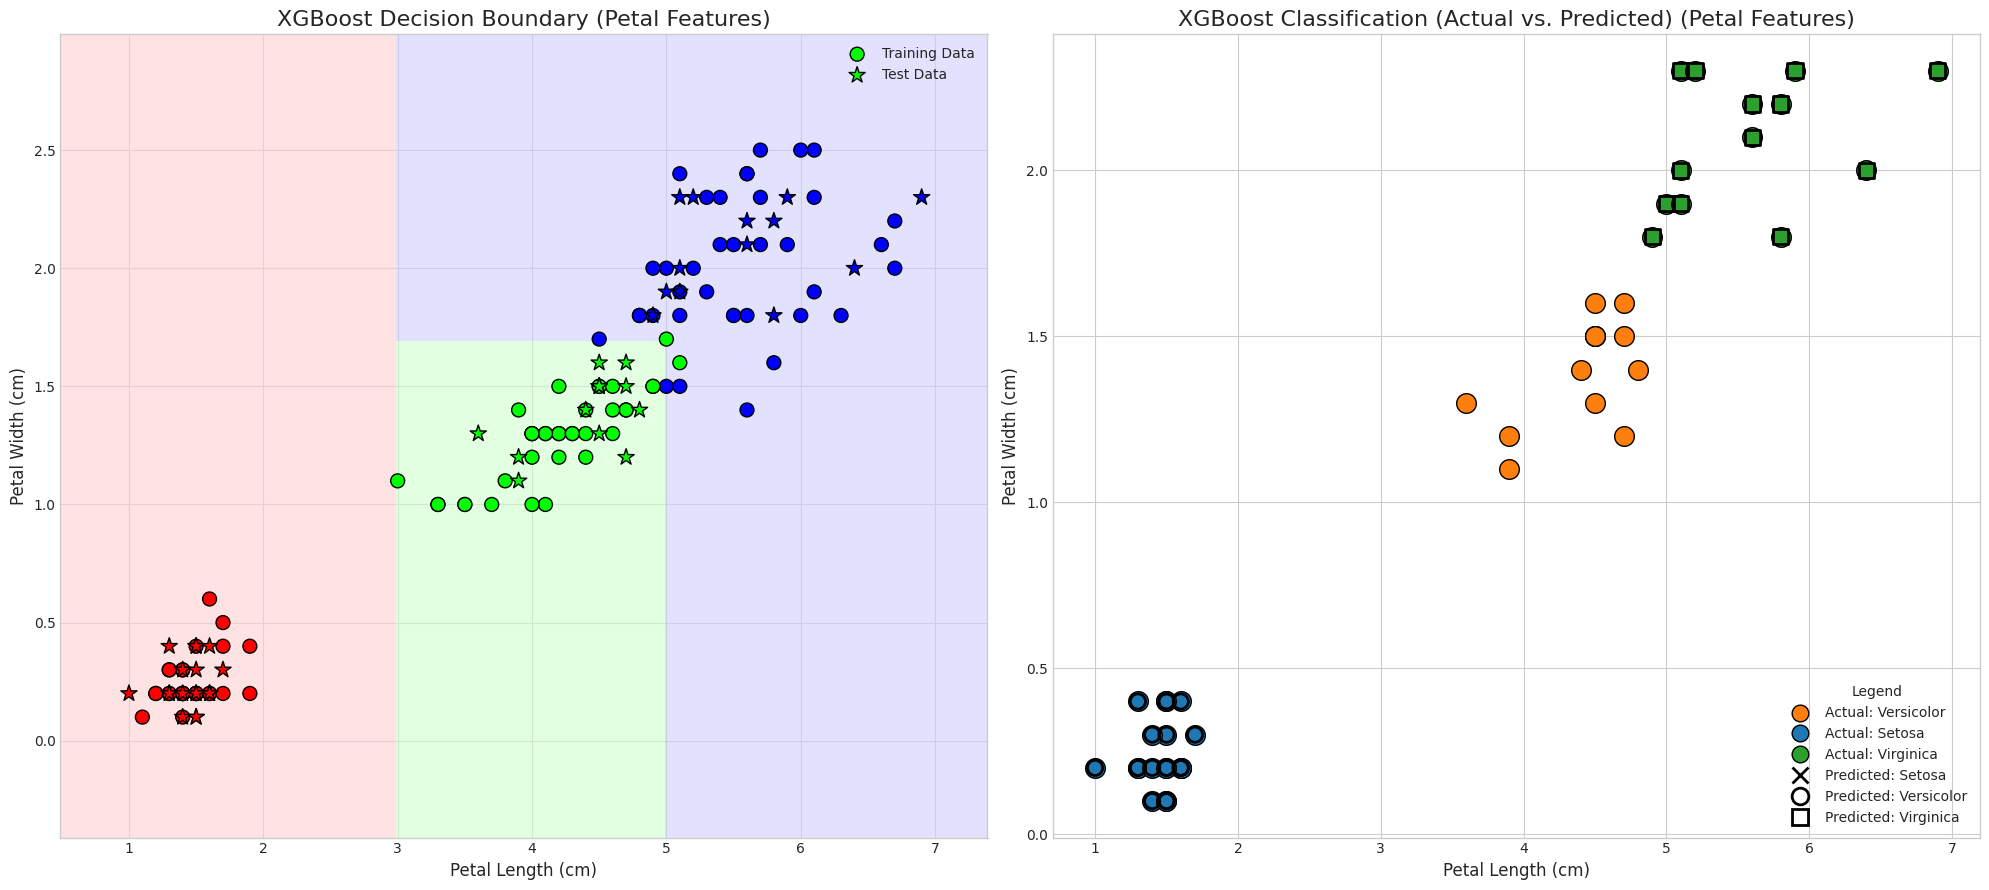


--- Classification Report (Model Trained on ALL Four Features) ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.datasets import load_iris

# --- Dataset setup ---
# We load the Iris dataset and use all four features for the model.
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names

# The features for visualization will be a subset of the full dataset
# We'll use petal length and petal width as they provide the best separation
X_plot = iris.data[:, 2:4]
feature_names_plot = ['petal length (cm)', 'petal width (cm)']

# Split the full dataset for training and testing the model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Get the corresponding test data for plotting
X_test_plot = X_test[:, 2:4]

# --- Model Building ---
# Initialize and train a single XGBoost model on all four features.
xgb = XGBClassifier(n_estimators=100, use_label_encoder=False, eval_metric='mlogloss', random_state=42)

print("Training the XGBoost model on ALL FOUR features...")
xgb.fit(X_train, y_train)
print("Training complete.\n")

# Make predictions on the test set (using all four features)
y_pred = xgb.predict(X_test)

# --- Plotting Both Graphs ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9))

# --- Graph 1: Decision Boundary Plot ---
# We'll use the trained model on a 2D meshgrid
cmap_light = ListedColormap(['#FFCFCF', '#CFFFCF', '#CFCFFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

x_min, x_max = X_plot[:, 0].min() - 0.5, X_plot[:, 0].max() + 0.5
y_min, y_max = X_plot[:, 1].min() - 0.5, X_plot[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Use a dummy array with zero values for the two unused features (sepal features)
dummy_features = np.zeros((xx.ravel().shape[0], 2))

# Combine the meshgrid with the dummy features to form a 4D input for prediction
X_mesh_4d = np.c_[dummy_features, xx.ravel(), yy.ravel()]
Z = xgb.predict(X_mesh_4d)
Z = Z.reshape(xx.shape)

ax1.pcolormesh(xx, yy, Z, cmap=cmap_light, shading='auto', alpha=0.6)

# Plot the training and test data on the 2D plot
ax1.scatter(X_train[:, 2], X_train[:, 3], c=y_train, cmap=cmap_bold,
            edgecolor='k', s=100, label='Training Data')
ax1.scatter(X_test_plot[:, 0], X_test_plot[:, 1], c=y_test, cmap=cmap_bold,
            marker='*', edgecolor='k', s=150, label='Test Data')

ax1.set_title("XGBoost Decision Boundary (Petal Features)", fontsize=16)
ax1.set_xlabel("Petal Length (cm)", fontsize=12)
ax1.set_ylabel("Petal Width (cm)", fontsize=12)
ax1.legend(loc='upper right')
ax1.grid(True)

# --- Graph 2: Actual vs. Predicted Plot ---
results_df = pd.DataFrame(X_test_plot, columns=feature_names_plot)
results_df['Actual Species'] = y_test
results_df['Predicted Species'] = y_pred

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
markers = ['o', 'x', 's']

for i, species_name in enumerate(iris.target_names):
    actual_indices = np.where(results_df['Actual Species'] == i)
    predicted_indices = np.where(results_df['Predicted Species'] == i)

    ax2.scatter(results_df.loc[actual_indices, feature_names_plot[0]],
                results_df.loc[actual_indices, feature_names_plot[1]],
                color=colors[i],
                marker='o',
                s=200,
                edgecolor='k',
                label=f'Actual: {species_name}')

    ax2.scatter(results_df.loc[predicted_indices, feature_names_plot[0]],
                results_df.loc[predicted_indices, feature_names_plot[1]],
                facecolors='none',
                edgecolor='k',
                marker=markers[i],
                s=120,
                linewidth=2,
                label=f'Predicted: {species_name}')

ax2.set_title('XGBoost Classification (Actual vs. Predicted) (Petal Features)', fontsize=16)
ax2.set_xlabel('Petal Length (cm)', fontsize=12)
ax2.set_ylabel('Petal Width (cm)', fontsize=12)

legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label='Actual: Versicolor',
               markerfacecolor=colors[1], markersize=12, markeredgecolor='k'),
    plt.Line2D([0], [0], marker='o', color='w', label='Actual: Setosa',
               markerfacecolor=colors[0], markersize=12, markeredgecolor='k'),
    plt.Line2D([0], [0], marker='o', color='w', label='Actual: Virginica',
               markerfacecolor=colors[2], markersize=12, markeredgecolor='k'),
    plt.Line2D([0], [0], marker='x', color='k', linestyle='None',
               label='Predicted: Setosa', markersize=12, markeredgewidth=2),
    plt.Line2D([0], [0], marker='o', color='k', linestyle='None',
               label='Predicted: Versicolor', markersize=12, markeredgewidth=2, fillstyle='none'),
    plt.Line2D([0], [0], marker='s', color='k', linestyle='None',
               label='Predicted: Virginica', markersize=12, markeredgewidth=2, fillstyle='none')
]

ax2.legend(handles=legend_elements, title='Legend', loc='lower right', fontsize=10)
ax2.grid(True)

plt.tight_layout()
plt.show()

# --- Print Classification Report ---
print("\n--- Classification Report (Model Trained on ALL Four Features) ---")
print(classification_report(y_test, y_pred, target_names=iris.target_names))

### Extreme Gradient Boost for Regression

Mean Squared Error: 0.54


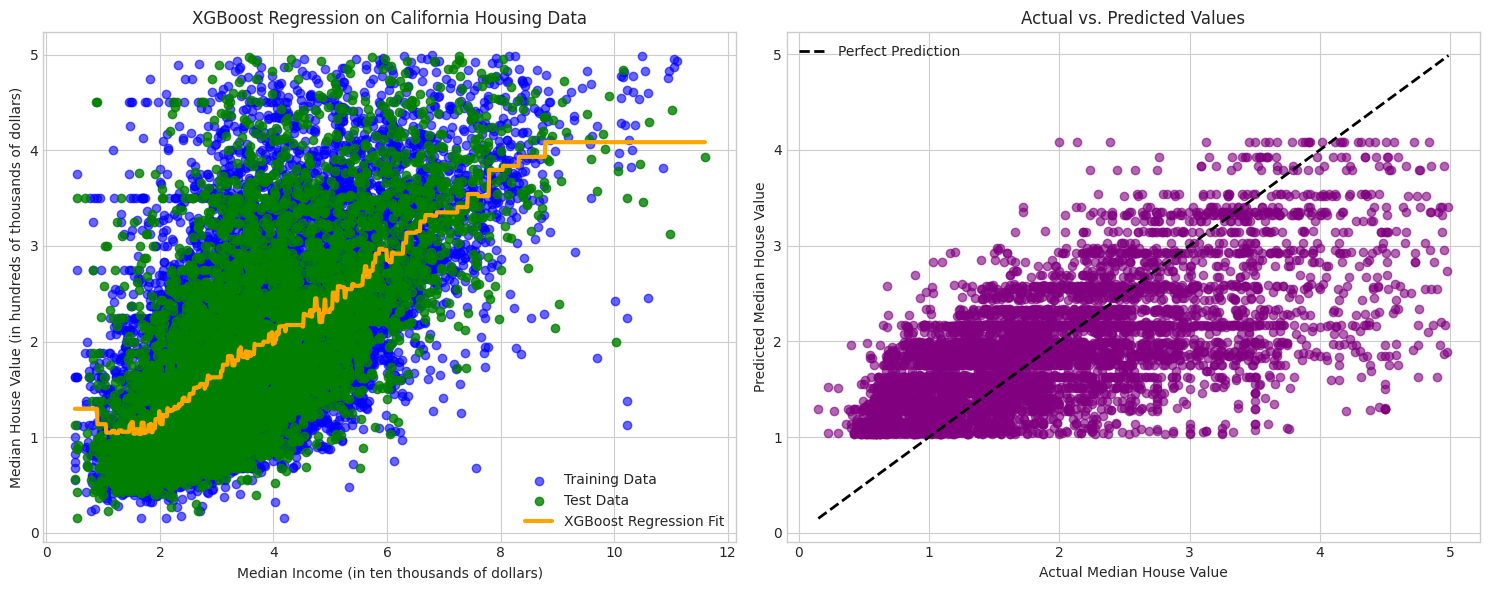

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.datasets import fetch_california_housing
import warnings
warnings.filterwarnings('ignore') # <- Note: Don't use this, this is only for this notebook

# --- Dataset Setup ---
# Load the California Housing dataset
california_housing = fetch_california_housing(as_frame=True)
X = california_housing.frame[['MedInc']]  # Using 'MedInc' (Median Income)
y = california_housing.target

# --- Data Cleaning ---
# 1. Remove rows where the target variable is truncated (equal to 5.0).
mask = y < 5.0
X_cleaned = X[mask]
y_cleaned = y[mask]

# 2. Remove extreme outliers based on median income.
# This helps the model focus on the main distribution.
# For example, filter out any income > 12.0
outlier_mask = X_cleaned['MedInc'] < 12.0
X_cleaned = X_cleaned[outlier_mask]
y_cleaned = y_cleaned[outlier_mask]

# Split the cleaned data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_cleaned, y_cleaned, test_size=0.3, random_state=42)

# --- Model Building ---
# Create and train the XGBoost Regressor model
# Using a few common parameters to start
xgb_regressor = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)
xgb_regressor.fit(X_train, y_train)

# Make predictions on the test set
y_pred = xgb_regressor.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")

# --- Plotting ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
plt.style.use('seaborn-v0_8-whitegrid')

# --- Plot 1: Regression Curve ---
# Generate predictions on a continuous range of X values to plot the regression curve
X_range = np.linspace(X_cleaned.min(), X_cleaned.max(), 1000).reshape(-1, 1)
y_range_pred = xgb_regressor.predict(X_range)

# Plot the training data points
ax1.scatter(X_train, y_train, color='blue', label='Training Data', alpha=0.6)

# Plot the testing data points
ax1.scatter(X_test, y_test, color='green', label='Test Data', alpha=0.8)

# Plot the XGBoost regression curve
ax1.plot(X_range, y_range_pred, color='orange', linewidth=3, label='XGBoost Regression Fit')

ax1.set_title("XGBoost Regression on California Housing Data")
ax1.set_xlabel("Median Income (in ten thousands of dollars)")
ax1.set_ylabel("Median House Value (in hundreds of thousands of dollars)")
ax1.legend()
ax1.grid(True)

# --- Plot 2: Actual vs. Predicted Values ---
ax2.scatter(y_test, y_pred, color='purple', alpha=0.6)
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Perfect Prediction')

ax2.set_title("Actual vs. Predicted Values")
ax2.set_xlabel("Actual Median House Value")
ax2.set_ylabel("Predicted Median House Value")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


---
## 4. CatBoost (Categorical Boosting) 
- CatBoost is a gradient boosting algorithm designed by Yandex with a novel approach to handling **categorical features** and a symmetric tree structure. 
- It uses an **ordered boosting** technique to prevent prediction shift (a form of target leakage), where it trains the model on a permutation of the data to calculate residuals, ensuring that the model does not learn from the future. 
- It replaces traditional one-hot encoding with a more robust, permutation-based strategy.
- **Numerical Equation:**
    - The model structure is similar to gradient boosting, but the training process is different:
    - $F(x) = \sum_{t=0}^{T} \alpha_t \cdot M_t(x)$
        - $M_t(x)$ is the $t^{th}$ tree trained on a permuted version of the data to avoid target leakage when handling categorical features.
- **Pseudocode:**
    ```
    Function CatBoost_Train(X, y, num_trees, learning_rate):
        // Initialize F_0
        F_m = initial_prediction(y)
        
        For m from 1 to num_trees:
            // 1. Randomly permute the data
            permuted_indices = shuffle_indices(X)
            X_permuted = X[permuted_indices]
            y_permuted = y[permuted_indices]
            
            // 2. Compute the pseudo-residuals based on the current model F_m
            // Note: The residuals are computed on the permuted data to avoid prediction shift
            residuals = -gradient(loss_function, y_permuted, F_m(X_permuted))
            
            // 3. Train a new tree h_m on the residuals
            // CatBoost uses a symmetric tree structure for efficiency and robustness
            h_m = train_catboost_tree(X_permuted, residuals, learning_rate)
            
            // 4. Update the model
            F_m = F_m + h_m
            
        Return F_m
    ```



### CatBoost for Classification

- The code will have the model trained on all 4 features (petal length, petal width, sepal length, sepal width).
- The plot to show decision boundary and predicted vs actual will only use petal length and petal width.

In [10]:
!pip install catboost

Training the CatBoost model on ALL FOUR features...
Training complete.



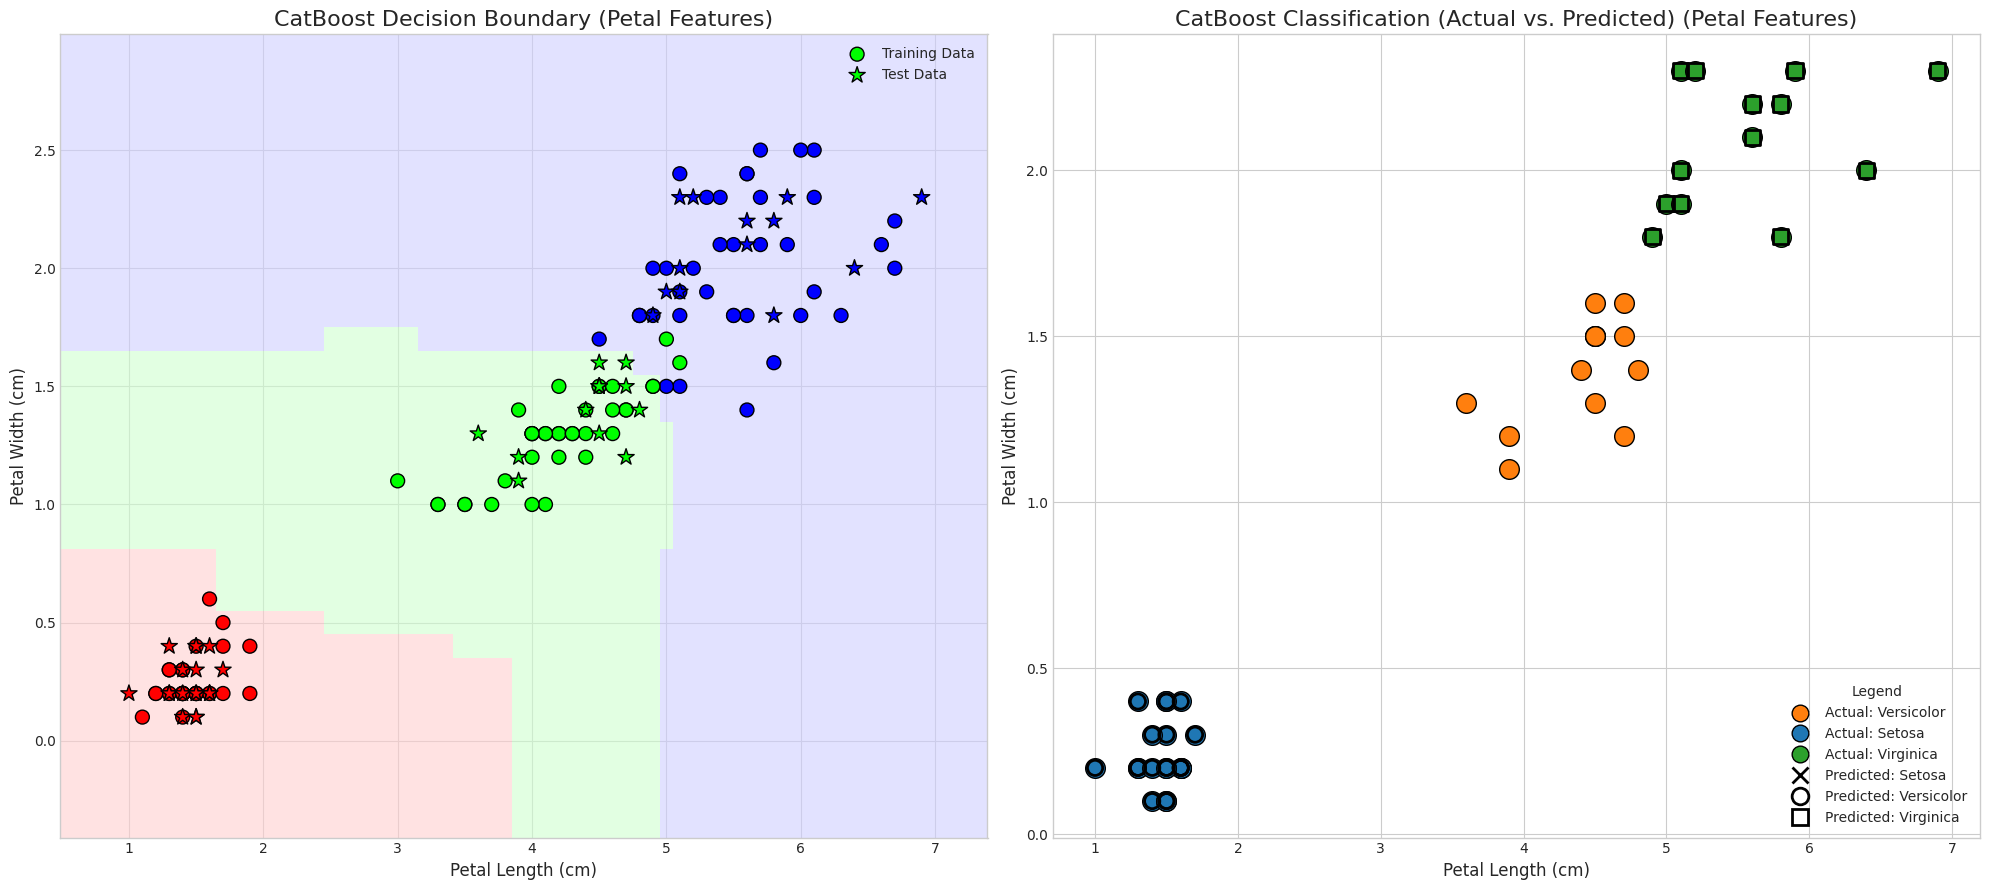


--- Classification Report (Model Trained on ALL Four Features) ---
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        19
  versicolor       1.00      1.00      1.00        13
   virginica       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sklearn.model_selection import train_test_split
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.datasets import load_iris
import seaborn as sns

# --- Dataset setup ---
# We load the Iris dataset and use all four features for the model.
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names

# The features for visualization will be a subset of the full dataset
# We'll use petal length and petal width as they provide the best separation
X_plot = iris.data[:, 2:4]
feature_names_plot = ['petal length (cm)', 'petal width (cm)']

# Split the full dataset for training and testing the model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Get the corresponding test data for plotting
X_test_plot = X_test[:, 2:4]

# --- Model Building ---
# Initialize and train a single CatBoost model on all four features.
# verbose=0 suppresses the extensive CatBoost training output
cbc = CatBoostClassifier(iterations=100, learning_rate=0.1, depth=3, verbose=0, random_state=42)

print("Training the CatBoost model on ALL FOUR features...")
cbc.fit(X_train, y_train)
print("Training complete.\n")

# Make predictions on the test set (using all four features)
y_pred = cbc.predict(X_test)

# --- Plotting Both Graphs ---
plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9))

# --- Graph 1: Decision Boundary Plot ---
# We'll use the trained model on a 2D meshgrid
cmap_light = ListedColormap(['#FFCFCF', '#CFFFCF', '#CFCFFF'])
cmap_bold = ListedColormap(['#FF0000', '#00FF00', '#0000FF'])

x_min, x_max = X_plot[:, 0].min() - 0.5, X_plot[:, 0].max() + 0.5
y_min, y_max = X_plot[:, 1].min() - 0.5, X_plot[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Use a dummy array with zeros for the two unused features (sepal features)
dummy_features = np.zeros((xx.ravel().shape[0], 2))

# Combine the meshgrid with the dummy features to form a 4D input for prediction
X_mesh_4d = np.c_[dummy_features, xx.ravel(), yy.ravel()]
Z = cbc.predict(X_mesh_4d)
Z = Z.reshape(xx.shape)

ax1.pcolormesh(xx, yy, Z, cmap=cmap_light, shading='auto', alpha=0.6)

# Plot the training and test data on the 2D plot
ax1.scatter(X_train[:, 2], X_train[:, 3], c=y_train, cmap=cmap_bold,
            edgecolor='k', s=100, label='Training Data')
ax1.scatter(X_test_plot[:, 0], X_test_plot[:, 1], c=y_test, cmap=cmap_bold,
            marker='*', edgecolor='k', s=150, label='Test Data')

ax1.set_title("CatBoost Decision Boundary (Petal Features)", fontsize=16)
ax1.set_xlabel("Petal Length (cm)", fontsize=12)
ax1.set_ylabel("Petal Width (cm)", fontsize=12)
ax1.legend(loc='upper right')
ax1.grid(True)

# --- Graph 2: Actual vs. Predicted Plot ---
results_df = pd.DataFrame(X_test_plot, columns=feature_names_plot)
results_df['Actual Species'] = y_test
results_df['Predicted Species'] = y_pred

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
markers = ['o', 'x', 's']

for i, species_name in enumerate(iris.target_names):
    actual_indices = np.where(results_df['Actual Species'] == i)
    predicted_indices = np.where(results_df['Predicted Species'] == i)

    ax2.scatter(results_df.loc[actual_indices, feature_names_plot[0]],
                results_df.loc[actual_indices, feature_names_plot[1]],
                color=colors[i],
                marker='o',
                s=200,
                edgecolor='k',
                label=f'Actual: {species_name}')

    ax2.scatter(results_df.loc[predicted_indices, feature_names_plot[0]],
                results_df.loc[predicted_indices, feature_names_plot[1]],
                facecolors='none',
                edgecolor='k',
                marker=markers[i],
                s=120,
                linewidth=2,
                label=f'Predicted: {species_name}')

ax2.set_title('CatBoost Classification (Actual vs. Predicted) (Petal Features)', fontsize=16)
ax2.set_xlabel('Petal Length (cm)', fontsize=12)
ax2.set_ylabel('Petal Width (cm)', fontsize=12)

legend_elements = [
    plt.Line2D([0], [0], marker='o', color='w', label='Actual: Versicolor',
               markerfacecolor=colors[1], markersize=12, markeredgecolor='k'),
    plt.Line2D([0], [0], marker='o', color='w', label='Actual: Setosa',
               markerfacecolor=colors[0], markersize=12, markeredgecolor='k'),
    plt.Line2D([0], [0], marker='o', color='w', label='Actual: Virginica',
               markerfacecolor=colors[2], markersize=12, markeredgecolor='k'),
    plt.Line2D([0], [0], marker='x', color='k', linestyle='None',
               label='Predicted: Setosa', markersize=12, markeredgewidth=2),
    plt.Line2D([0], [0], marker='o', color='k', linestyle='None',
               label='Predicted: Versicolor', markersize=12, markeredgewidth=2, fillstyle='none'),
    plt.Line2D([0], [0], marker='s', color='k', linestyle='None',
               label='Predicted: Virginica', markersize=12, markeredgewidth=2, fillstyle='none')
]

ax2.legend(handles=legend_elements, title='Legend', loc='lower right', fontsize=10)
ax2.grid(True)

plt.tight_layout()
plt.show()

# --- Print Classification Report ---
print("\n--- Classification Report (Model Trained on ALL Four Features) ---")
print(classification_report(y_test, y_pred, target_names=iris.target_names))


### CatBoost for Regression

Mean Squared Error: 0.53


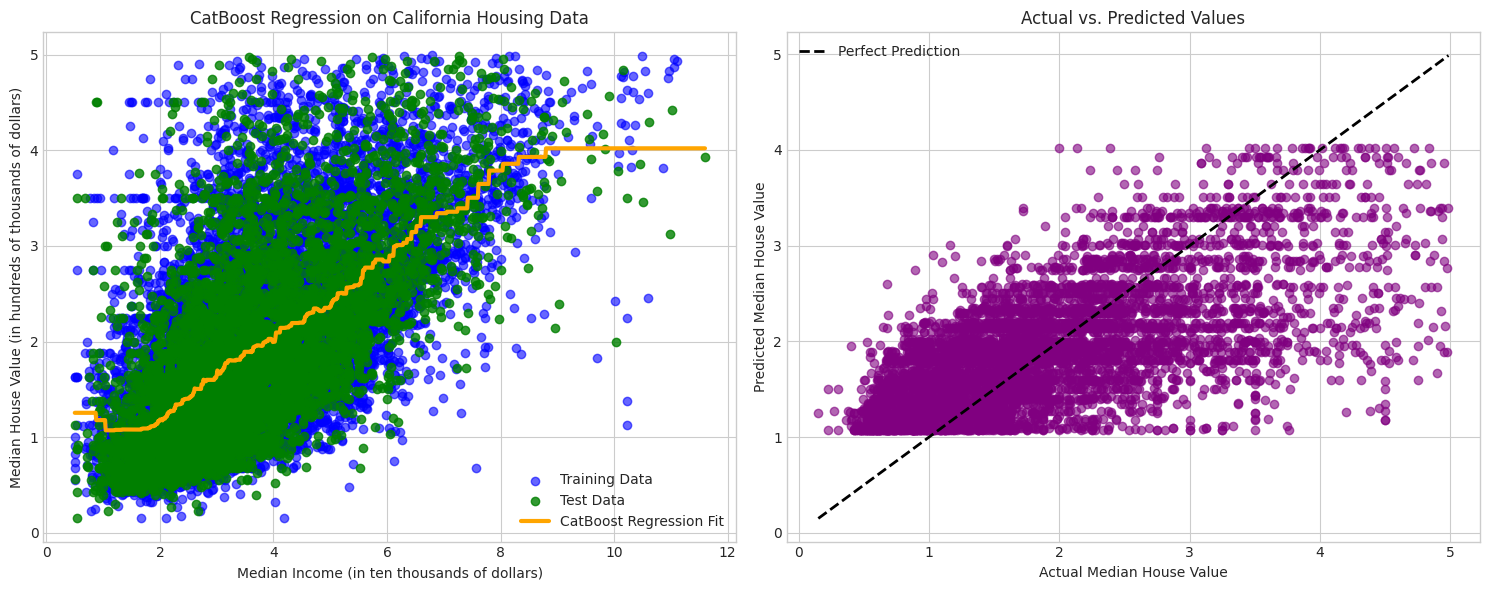

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from catboost import CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.datasets import fetch_california_housing
import warnings
warnings.filterwarnings('ignore') # <- Note: Don't use this, this is only for this notebook

# --- Dataset Setup ---
# Load the California Housing dataset
california_housing = fetch_california_housing(as_frame=True)
X = california_housing.frame[['MedInc']]  # Using 'MedInc' (Median Income)
y = california_housing.target

# --- Data Cleaning ---
# 1. Remove rows where the target variable is truncated (equal to 5.0).
mask = y < 5.0
X_cleaned = X[mask]
y_cleaned = y[mask]

# 2. Remove extreme outliers based on median income.
# This helps the model focus on the main distribution.
# For example, filter out any income > 12.0
outlier_mask = X_cleaned['MedInc'] < 12.0
X_cleaned = X_cleaned[outlier_mask]
y_cleaned = y_cleaned[outlier_mask]

# Split the cleaned data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_cleaned, y_cleaned, test_size=0.3, random_state=42)

# --- Model Building ---
# Create and train the CatBoost Regressor model
cb_regressor = CatBoostRegressor(iterations=100, learning_rate=0.1, depth=3, random_state=42, verbose=0)
cb_regressor.fit(X_train, y_train)

# Make predictions on the test set
y_pred = cb_regressor.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")

# --- Plotting ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
plt.style.use('seaborn-v0_8-whitegrid')

# --- Plot 1: Regression Curve ---
# Generate predictions on a continuous range of X values to plot the regression curve
X_range = np.linspace(X_cleaned.min(), X_cleaned.max(), 1000).reshape(-1, 1)
y_range_pred = cb_regressor.predict(X_range)

# Plot the training data points
ax1.scatter(X_train, y_train, color='blue', label='Training Data', alpha=0.6)

# Plot the testing data points
ax1.scatter(X_test, y_test, color='green', label='Test Data', alpha=0.8)

# Plot the CatBoost regression curve
ax1.plot(X_range, y_range_pred, color='orange', linewidth=3, label='CatBoost Regression Fit')

ax1.set_title("CatBoost Regression on California Housing Data")
ax1.set_xlabel("Median Income (in ten thousands of dollars)")
ax1.set_ylabel("Median House Value (in hundreds of thousands of dollars)")
ax1.legend()
ax1.grid(True)

# --- Plot 2: Actual vs. Predicted Values ---
ax2.scatter(y_test, y_pred, color='purple', alpha=0.6)
ax2.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Perfect Prediction')

ax2.set_title("Actual vs. Predicted Values")
ax2.set_xlabel("Actual Median House Value")
ax2.set_ylabel("Predicted Median House Value")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

---
# Summary  

| Model | Primary Task(s) | Notes |
| :--- | :--- | :--- |
| **Linear Regression** | Regression | A fundamental model for predicting a continuous target. |
| **Random Forest** | Regression, Classification | A versatile ensemble model that averages predictions for regression or uses a majority vote for classification. |
| **Gradient Boost** | Regression, Classification | A powerful sequential ensemble that can be used for both tasks by minimizing the appropriate loss function. |
| **XGBoost** | Regression, Classification | An optimized and highly scalable implementation of gradient boosting, widely used for both regression and classification. |
| **CatBoost** | Regression, Classification | A gradient boosting model with specific features for handling categorical data, suitable for both tasks. |
| **KNN** | Regression, Classification | A non-parametric model that predicts based on the average (regression) or majority class (classification) of its k-nearest neighbors. |
| **SGD** | Optimization | This is an **optimizer**, not a standalone model. It's used to train other models (like linear regression, logistic regression, or neural networks) by minimizing the loss function. |
| **Perceptron** | Classification | A foundational model for **binary classification**, it's a linear classifier. |
| **Gaussian Naive Bayes** | Classification | A probabilistic model based on Bayes' theorem, commonly used for multi-class classification problems. |